# Data visualisations in R

## An Introduction to Data Visualisation in R: From Base Scatter Plots to facetting ggplots.

### **Introduction**

R is known to be a really powerful programming language which started as a statistical software. It has now moved beyond its origin is now capable of a range of applications such as graphics and visualisations. R has a diverse library of graphics packages and functions, which allows for the creation of various types of plots and graphs for visualising data in meanful ways. 

Graphics in R can be done in three ways, via the:

- `{graphics}` package (the base graphics in R, loaded by default)
- `{lattice}` package which adds more functionalities to the base package
- `{ggplot2}` package (which needs to be installed and loaded beforehand)

The `{graphics}` package comes with a large choice of plots (such as `plot`, `hist`, `barplot`, `boxplot`, `pie`, `mosaicplot`, etc.) and additional related features (e.g., `abline`, `lines`, `legend`, `mtext`, `rect`, etc.). It is often the preferred way to draw plots for most R users, and in particular for beginners to intermediate users.

Since its development in 2005 by Hadley Wickham, `{ggplot2}` has grown to become one of the most popular R packages and the most popular package for graphics and data visualizations. The `{ggplot2}` package is a much more modern approach to creating professional-quality graphics. More information about the package can be found at [ggplot2.tidyverse.org](https://ggplot2.tidyverse.org).

<div style="clear: both;"></div>

Some of the interesting features of R graphics include:

- **Customisability:** Plots can be highly customised, from axis labels and titles to colours, markers, and themes.
- **Wide range of plot types:** R offers a variety of plot types, including scatter plots, line plots, bar plots, histograms, density plots, box plots, and more.
- **Integration with data analysis:** R graphics integrates well with the data analysis functions in R, making it easy to plot the results of statistical models and analyses.
- **Interactivity:** R graphics can be made interactive, allowing users to zoom, pan, and hover over data points to reveal more information.
- **Publication-quality:** R graphics can be generated in a high-resolution format suitable for printing or publishing, making it a popular choice for academic and scientific publications.

### **Base visualisations**

We are going to be working on custom created data and visualise it using base plot functions. The custom data is of Soil pH levels measured across different Forest Sites over several decades.

In [1]:
# Create data

Year <- seq(from = 1950, to = 2023, by = 1)
Site <- c("Coniferous", "Deciduous", "Grassland")
Sample <- seq(from = 1, to = 10, by = 1)

df <- expand.grid(Year = Year, Site = Site, Sample = Sample)


pH_Value <- rnorm(n = nrow(df), mean = 6.5, sd = 0.8)

df$pH_Value <- pH_Value

For the sake of it, I will configure the plots so that they appear larger for better visualisations

In [2]:
options(
  repr.plot.width  = 9,
  repr.plot.height = 6,
  repr.plot.res    = 200
)

# These options center our plots and gives them a better resolution than default. 

The base `plot()` function will create a grid that is each column of the data set plotted against all the others, this is fine for continuous data. 

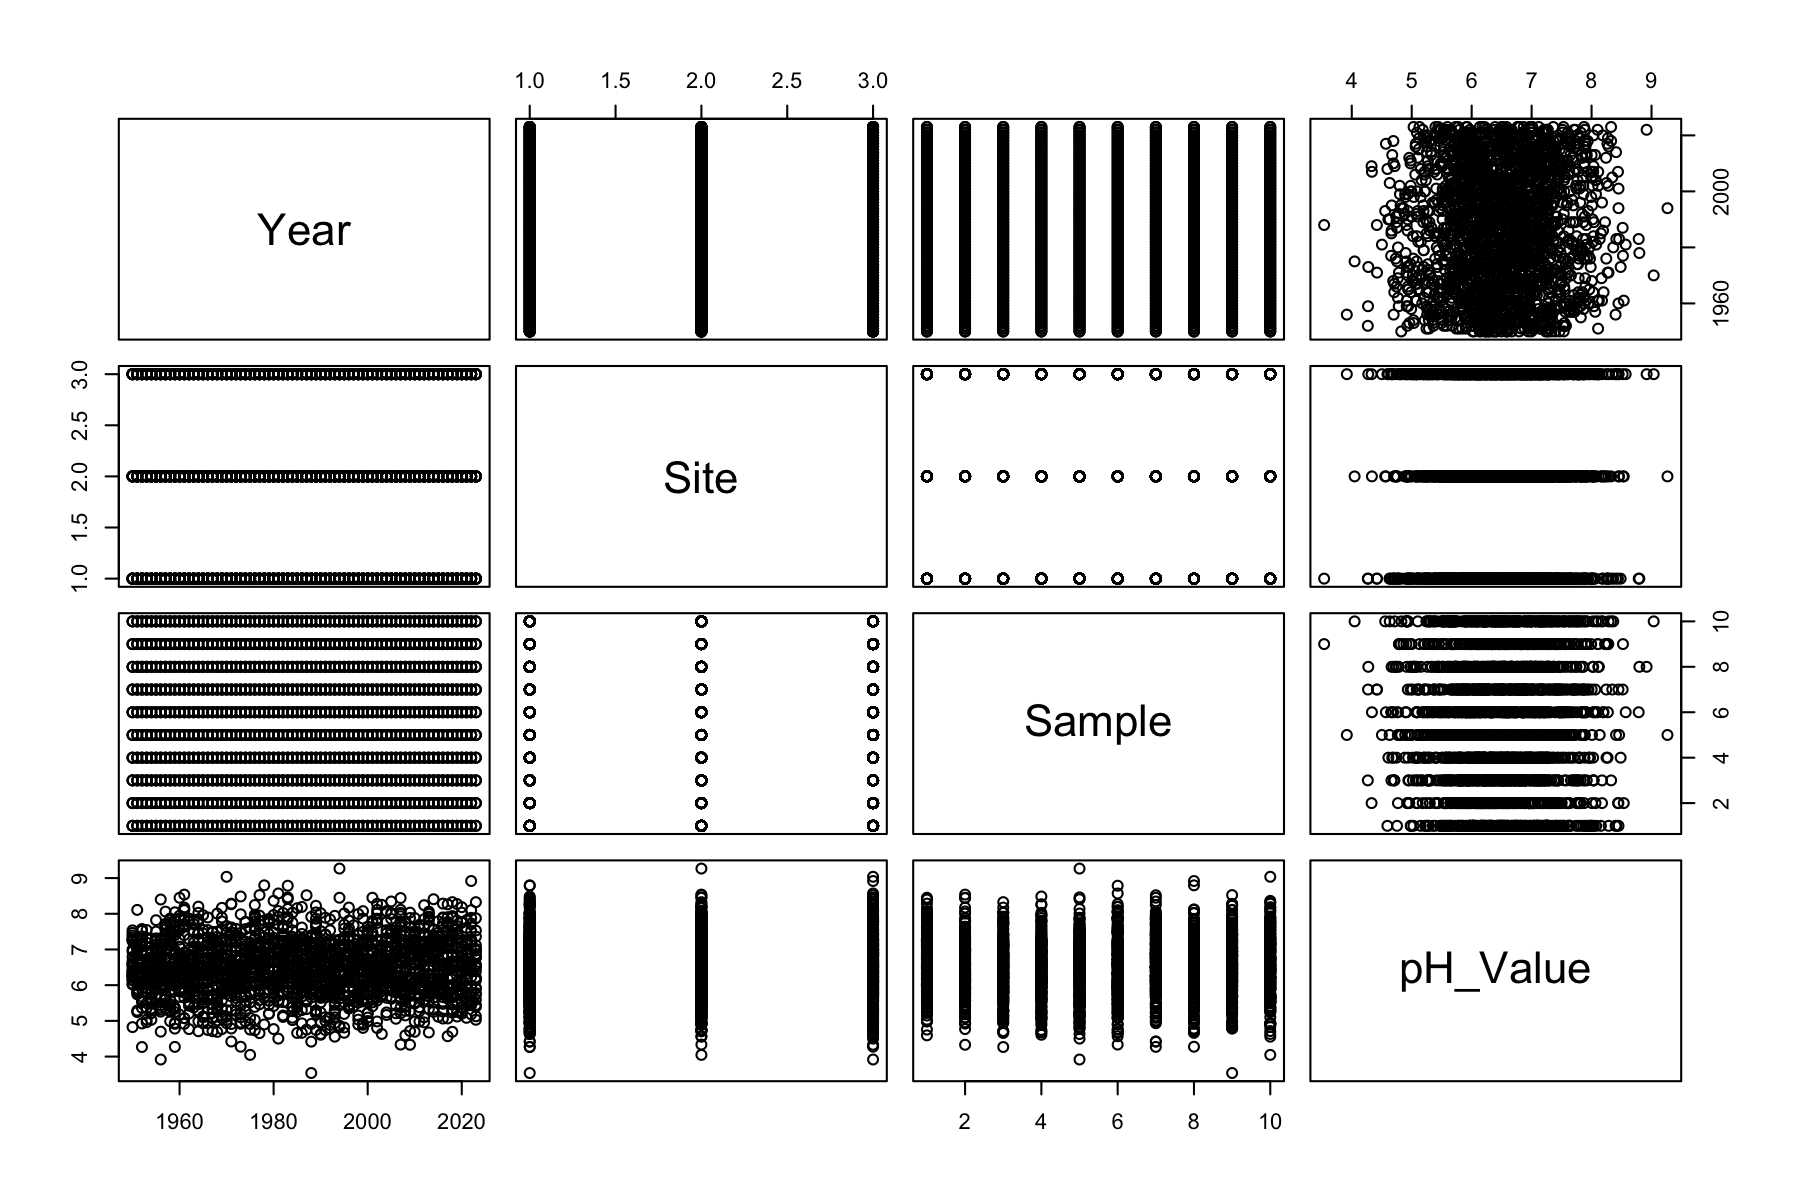

In [3]:
plot(df)

We can define x and y axes from columns of the data set

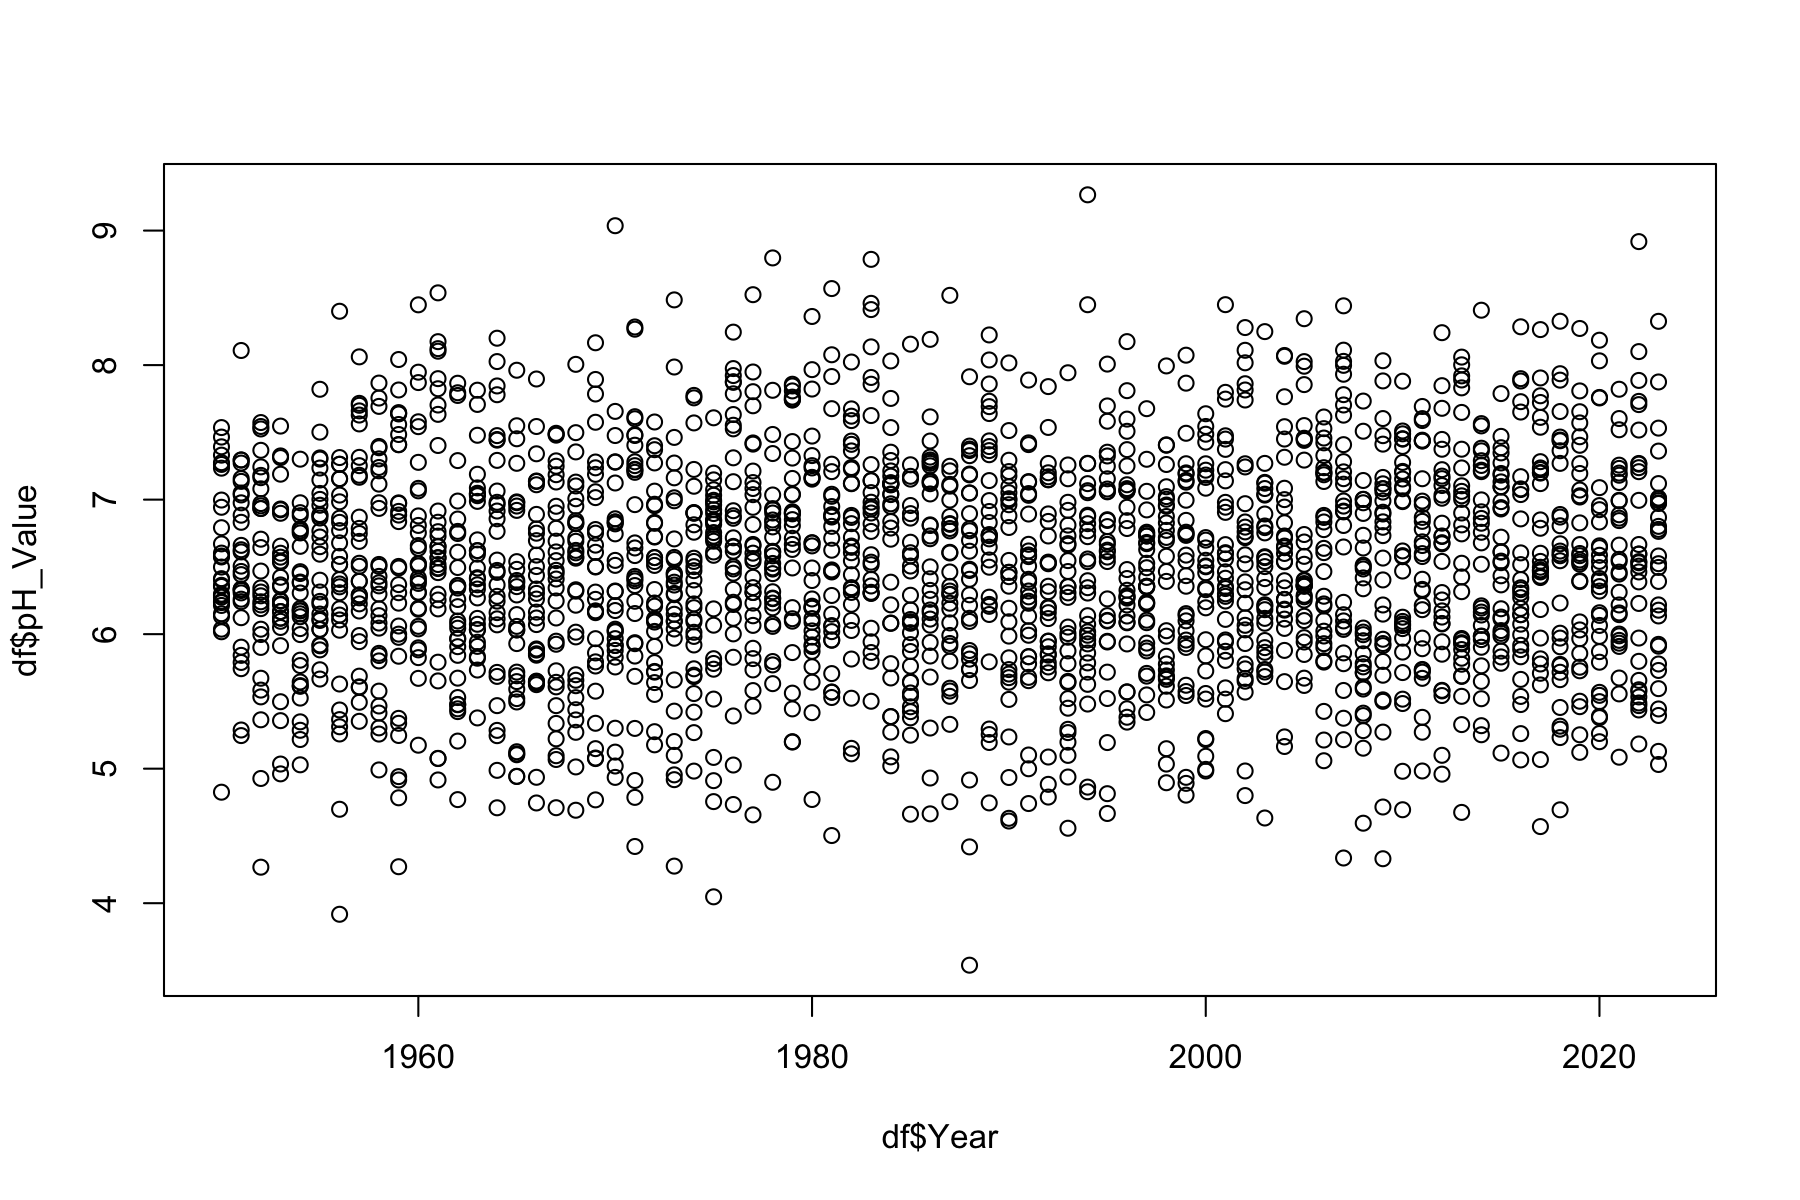

In [4]:
plot(x = df$Year, y = df$pH_Value)

It automatically does a scatter plot, maybe we want to colour different sites differently, and perhaps some axis labels that are more clear?

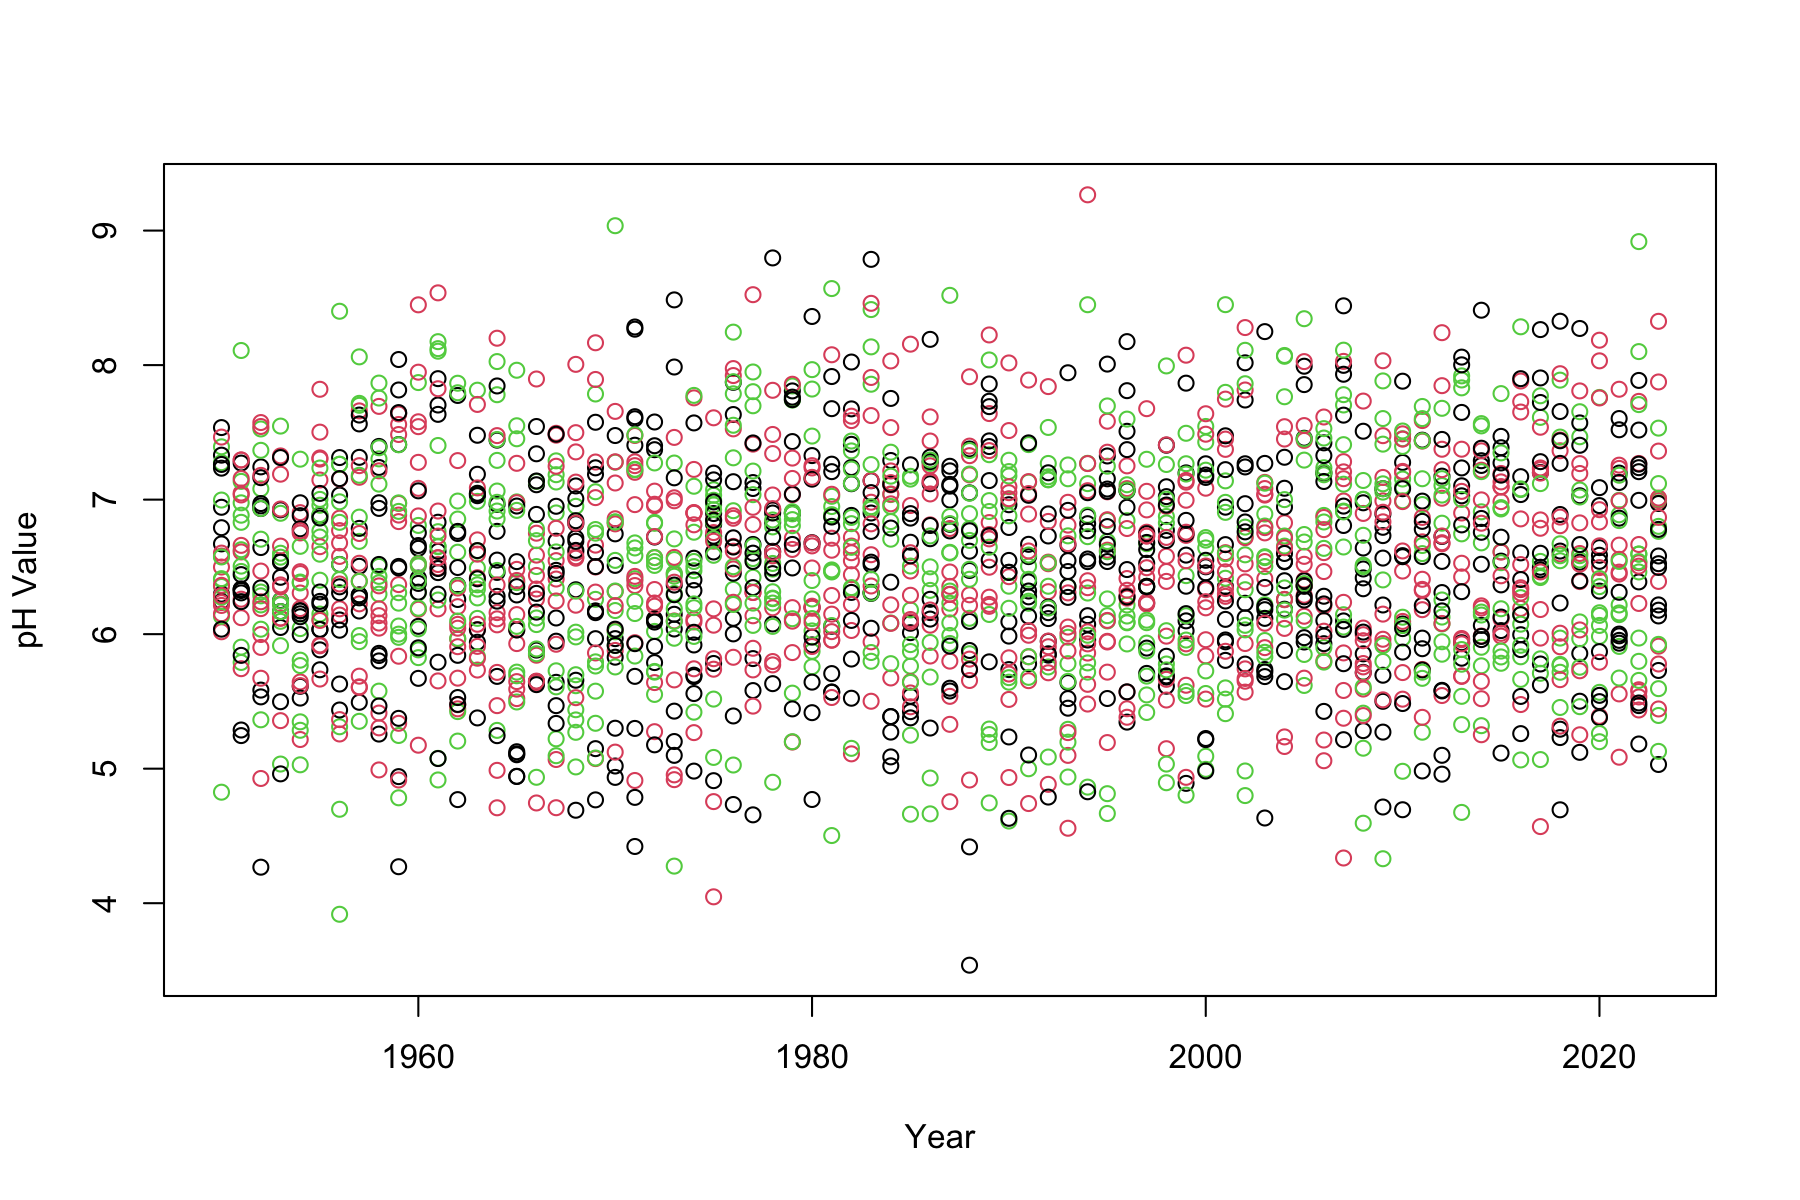

In [6]:
plot(x = df$Year,
     y = df$pH_Value,
     col = df$Site, # Colours by site
     xlab = "Year",      # Adds x-axis label
     ylab = "pH Value")  # Adds y-axis label

Some of the arguments in this function are well named but you need to know the names of the arguments to properly use a function best. You can easily find documentation of what arguments are within a function by typing two **?** before the function in the console like so:

In [ ]:
?plot()

# plot is a common function name 
# so we have to go to the base::plot() section of the help

With the points coloured we should add a legend to the plot, this is accomplished with another function run after the plot function.

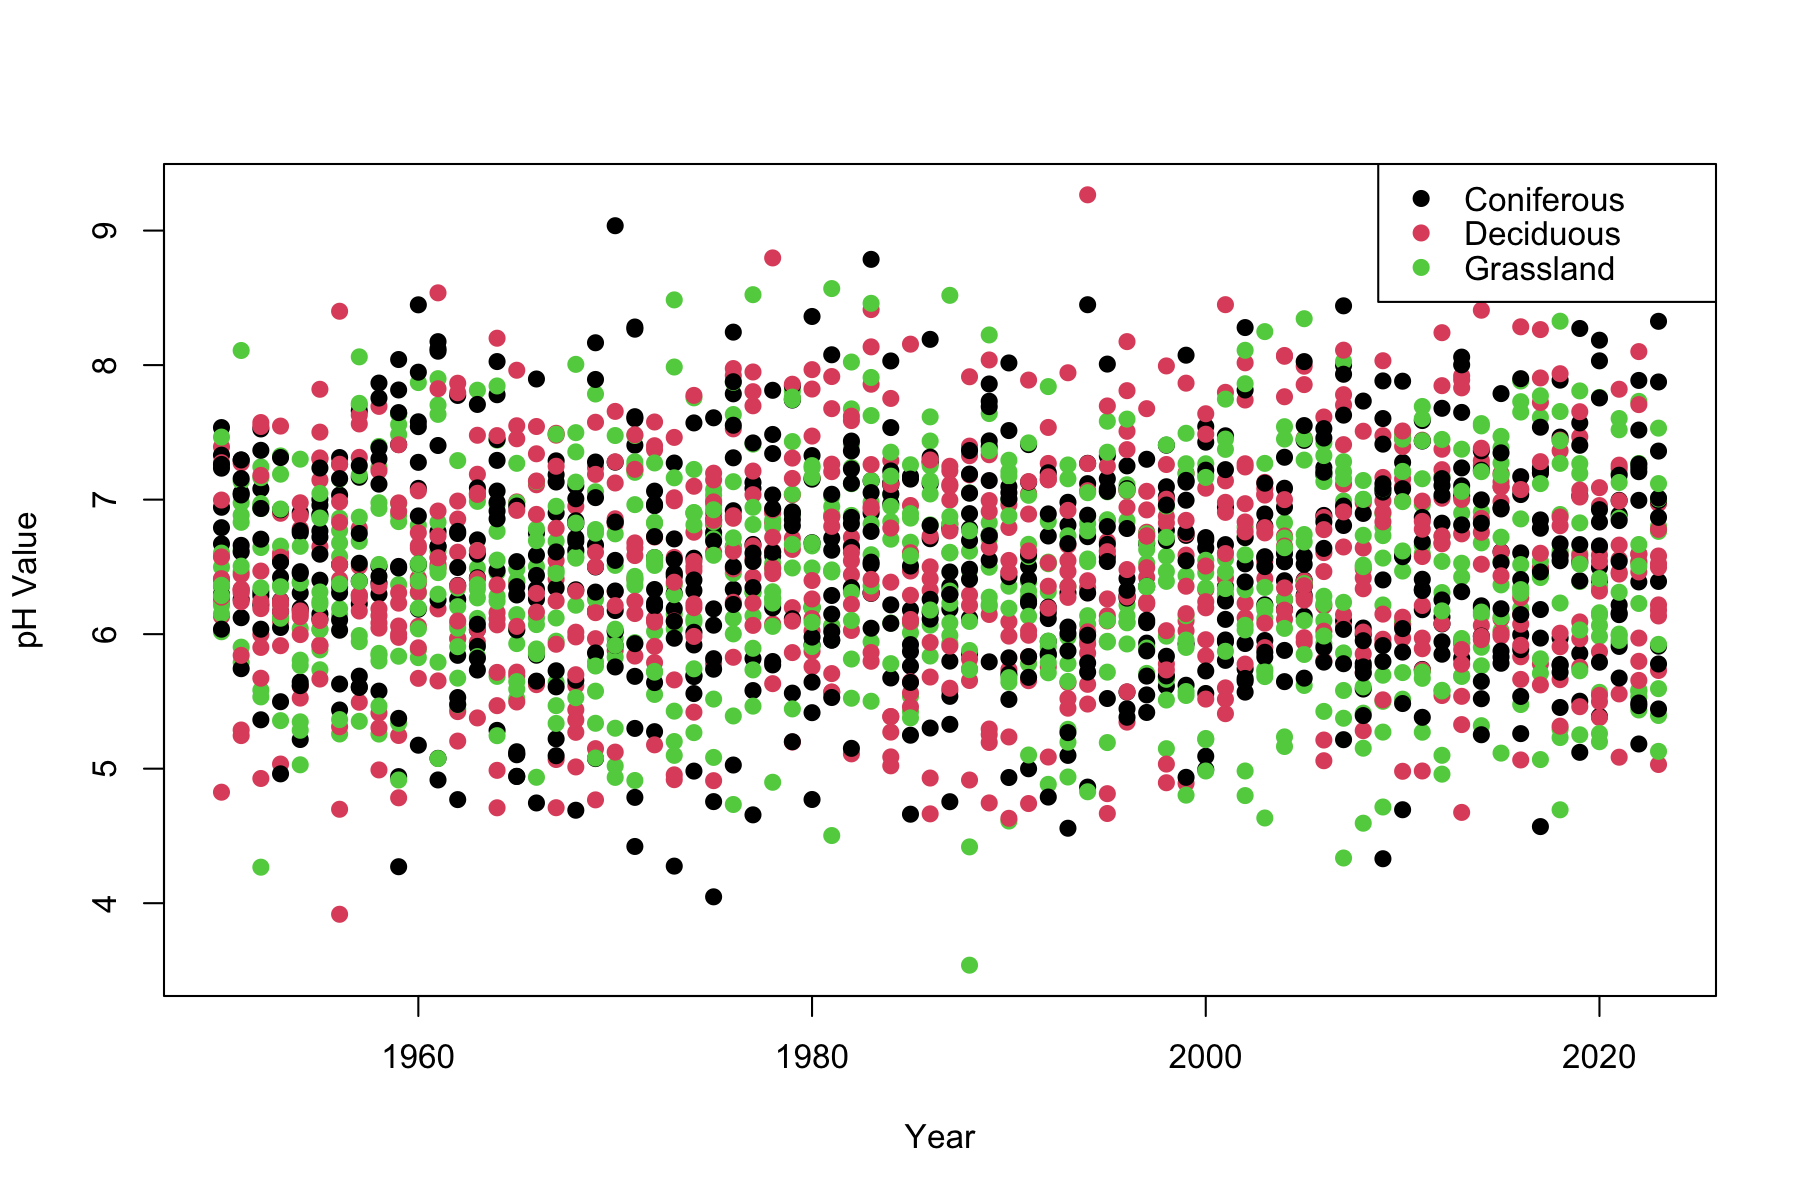

In [7]:
plot(x=df$Year,
     y=df$pH_Value,
     col=unique(df$Site), 
     xlab="Year",
     ylab="pH Value",
     pch=19)
legend(x = "topright",                 # Position
       legend = unique(df$Site),       # Legend texts
       col = c(1,2, 3),                # point colors
       pch=19)                         # point type

We can see that the pH value is totally random, regardless of site and year.

To make even more interesting plots, we can change this. We can add patterns and jitter (random noise) to our data based on its pH value. We will use some of our data manipulation code to do this.

In [9]:
library(tidyverse)

In [10]:
df_1 <- df %>% 
  mutate(pH_updated = case_when(
    Site == "Coniferous" ~ jitter(pH_Value)*((Year-1930)/5)-50,
    Site == "Deciduous" ~ jitter(pH_Value)*((Year-1930)*-2)+1000,
    Site == "Grassland" ~ jitter(pH_Value)*((Year-1930)*1.5)-4))

We can now calculate some summary statistics such as **mean** or **standard deviation** using `group_by()` and `summarise()`.

In [11]:
df_1_summary <- df_1 %>% 
  group_by(Site) %>% 
  summarise(Mean_pH = mean(pH_updated),
            SD_pH = sd(pH_updated))

df_1_summary

Site,Mean_pH,SD_pH
<fct>,<dbl>,<dbl>
Coniferous,23.37614,29.89081
Deciduous,263.17354,297.64938
Grassland,547.86310,221.85285


In [12]:
df_1_summary_year <- df_1 %>% 
  group_by(Site, Year) %>% 
  summarise(Mean_pH = mean(pH_updated),
            SD_pH = sd(pH_updated))

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Site and Year.
ℹ Output is grouped by Site.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Site, Year))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


In [13]:
df_1_summary_year

Site,Year,Mean_pH,SD_pH
<fct>,<dbl>,<dbl>,<dbl>
Coniferous,1950,-22.6622123,2.063561
Coniferous,1951,-24.1143473,2.477069
Coniferous,1952,-21.9991830,4.205591
Coniferous,1953,-21.1747758,3.086065
Coniferous,1954,-20.0471992,2.395364
Coniferous,1955,-18.3700146,2.266767
Coniferous,1956,-16.7818666,3.278274
Coniferous,1957,-14.1912576,3.705274
Coniferous,1958,-14.5593018,4.345770


<img src="Logos/ggplot logo.png" style="float: left; margin-right: 15px;" width="90"> 

### **`{ggplot2}`**

To make more complex (as well as simple) plots, `{ggplot2}` is by far the best package to use. The gg in `{ggplot2}` stands for grammar of graphics, which is a very old framework for good visualisations. 

There are three models to keep in mind when working with `{ggplot2}`:

- `{ggplot2}` builds plots by accumulation, not transformation. You start with a base layer and add components.
- Aesthetics are either data-driven or constant — never both. If it comes from data, it belongs inside aes(). If it is a fixed value, it belongs outside.
- Grouping is not decoration; it is data identity. It tells ggplot which observations belong together.

In every plot we will want to plot Data, it can be of however many dimensions and values. we then would want to assign some elements of the data to the elements of the plot, this is called mapping. Mapping changes based on the geometry (shape/style). For example, earlier with base plot, we mapped a column (Data) to be the x-axis and another to be the y-axis. Base plot assumed that our geometry was a scatter plot based on the data.

Using these principles, we can build very impressive and complex plots. we will first have to make a blank ggplot saying what data we will include using `ggplot()`. For elements of the plot (aesthetics) that change with the data from the df, we the `aes()` function to show what column we want to map to what element (`mapping = aes()`). Then we want to add layers (geometries) to the plot for what we want to plot and how we want it to look.

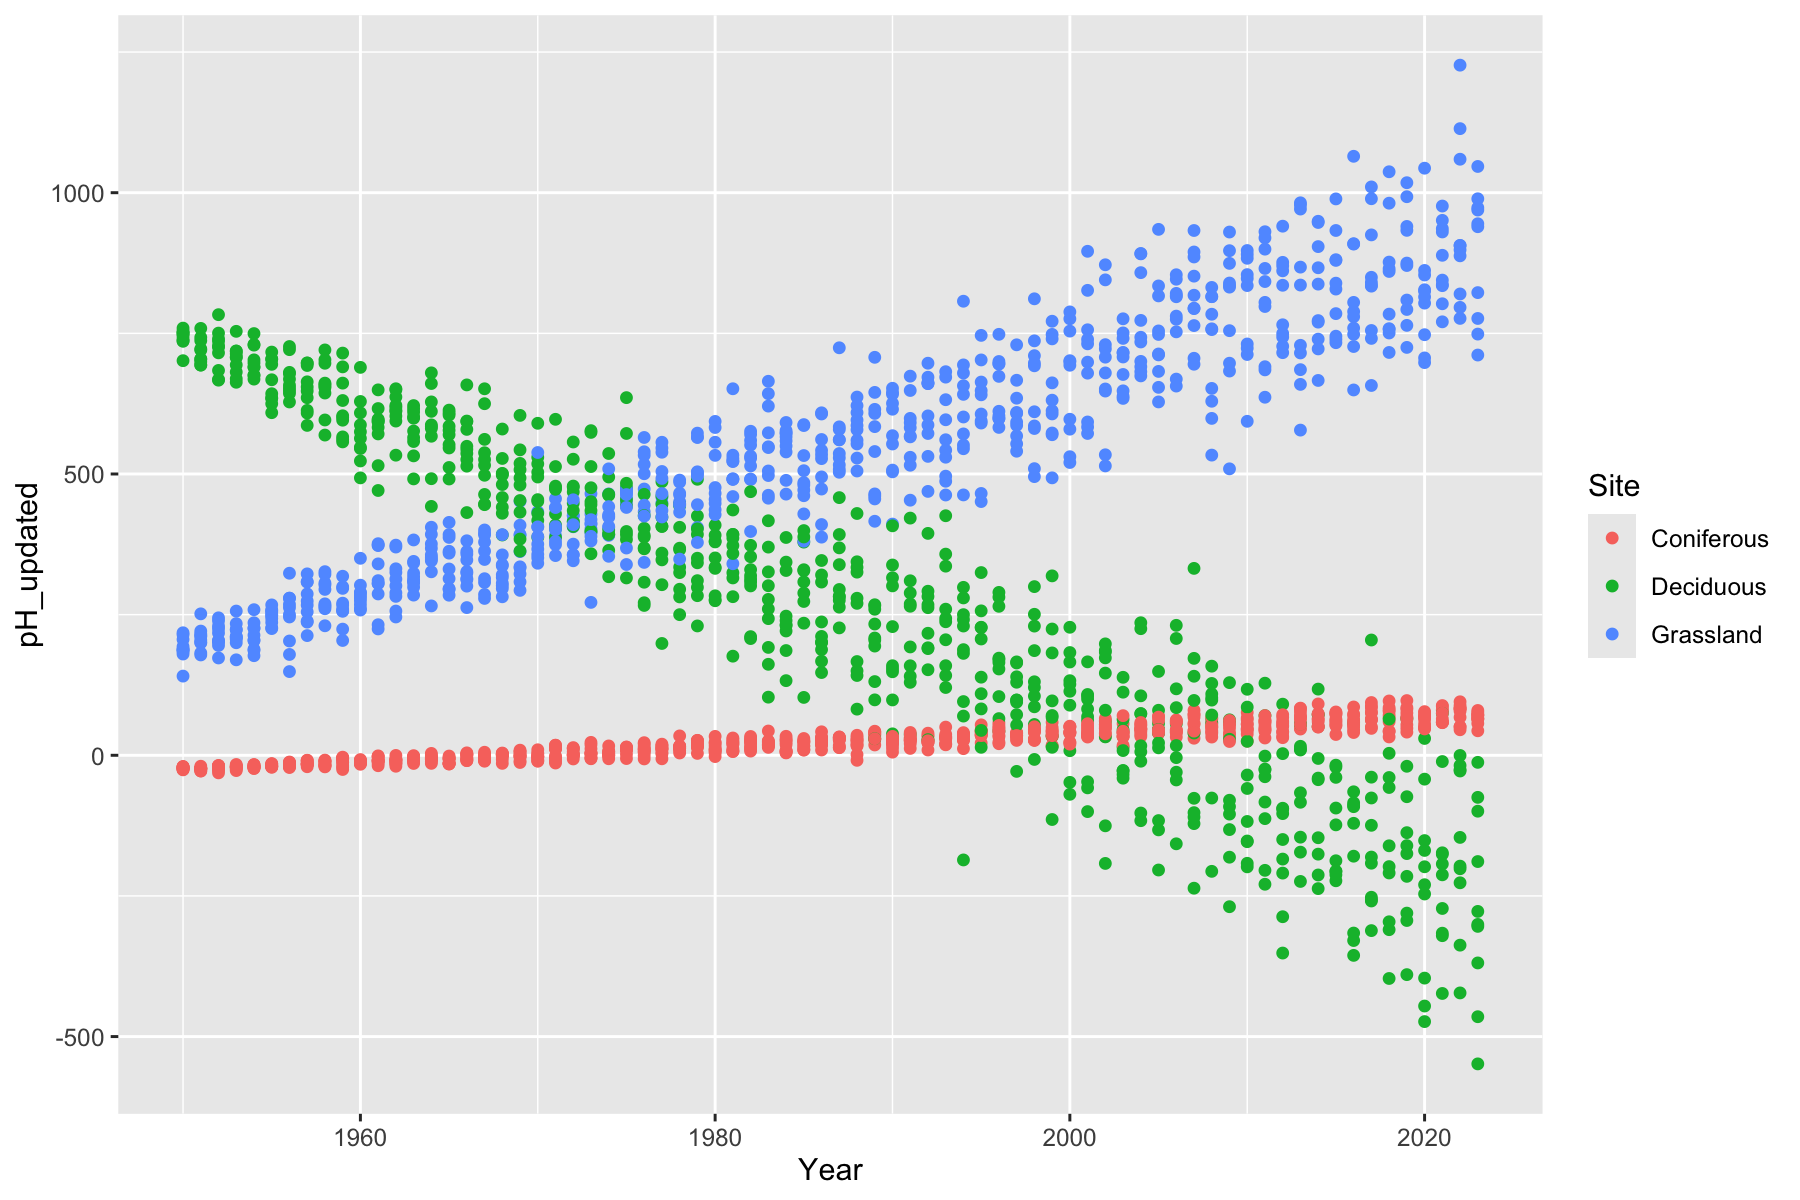

In [14]:
# Continue with the custom data

ggplot(data = df_1,
       mapping = aes(x = Year,
                   y = pH_updated,
                   colour = Site))+
  geom_point()

Overall the plot looks good but it could be better. There are plenty geom types to dictate the type of plot we want. Different geom types have different aesthetic elements required. We could check them by using `??geom_point` for example. generally we would use x, y, colour, fill and alpha (transparency)... Sometimes z or label or many others. 

Unlike base plotting, `ggplot()` creates a legend automatically. This becomes more and more complex as the plot becomes more complex, but is generally a nice default.

#### Same data, different plots

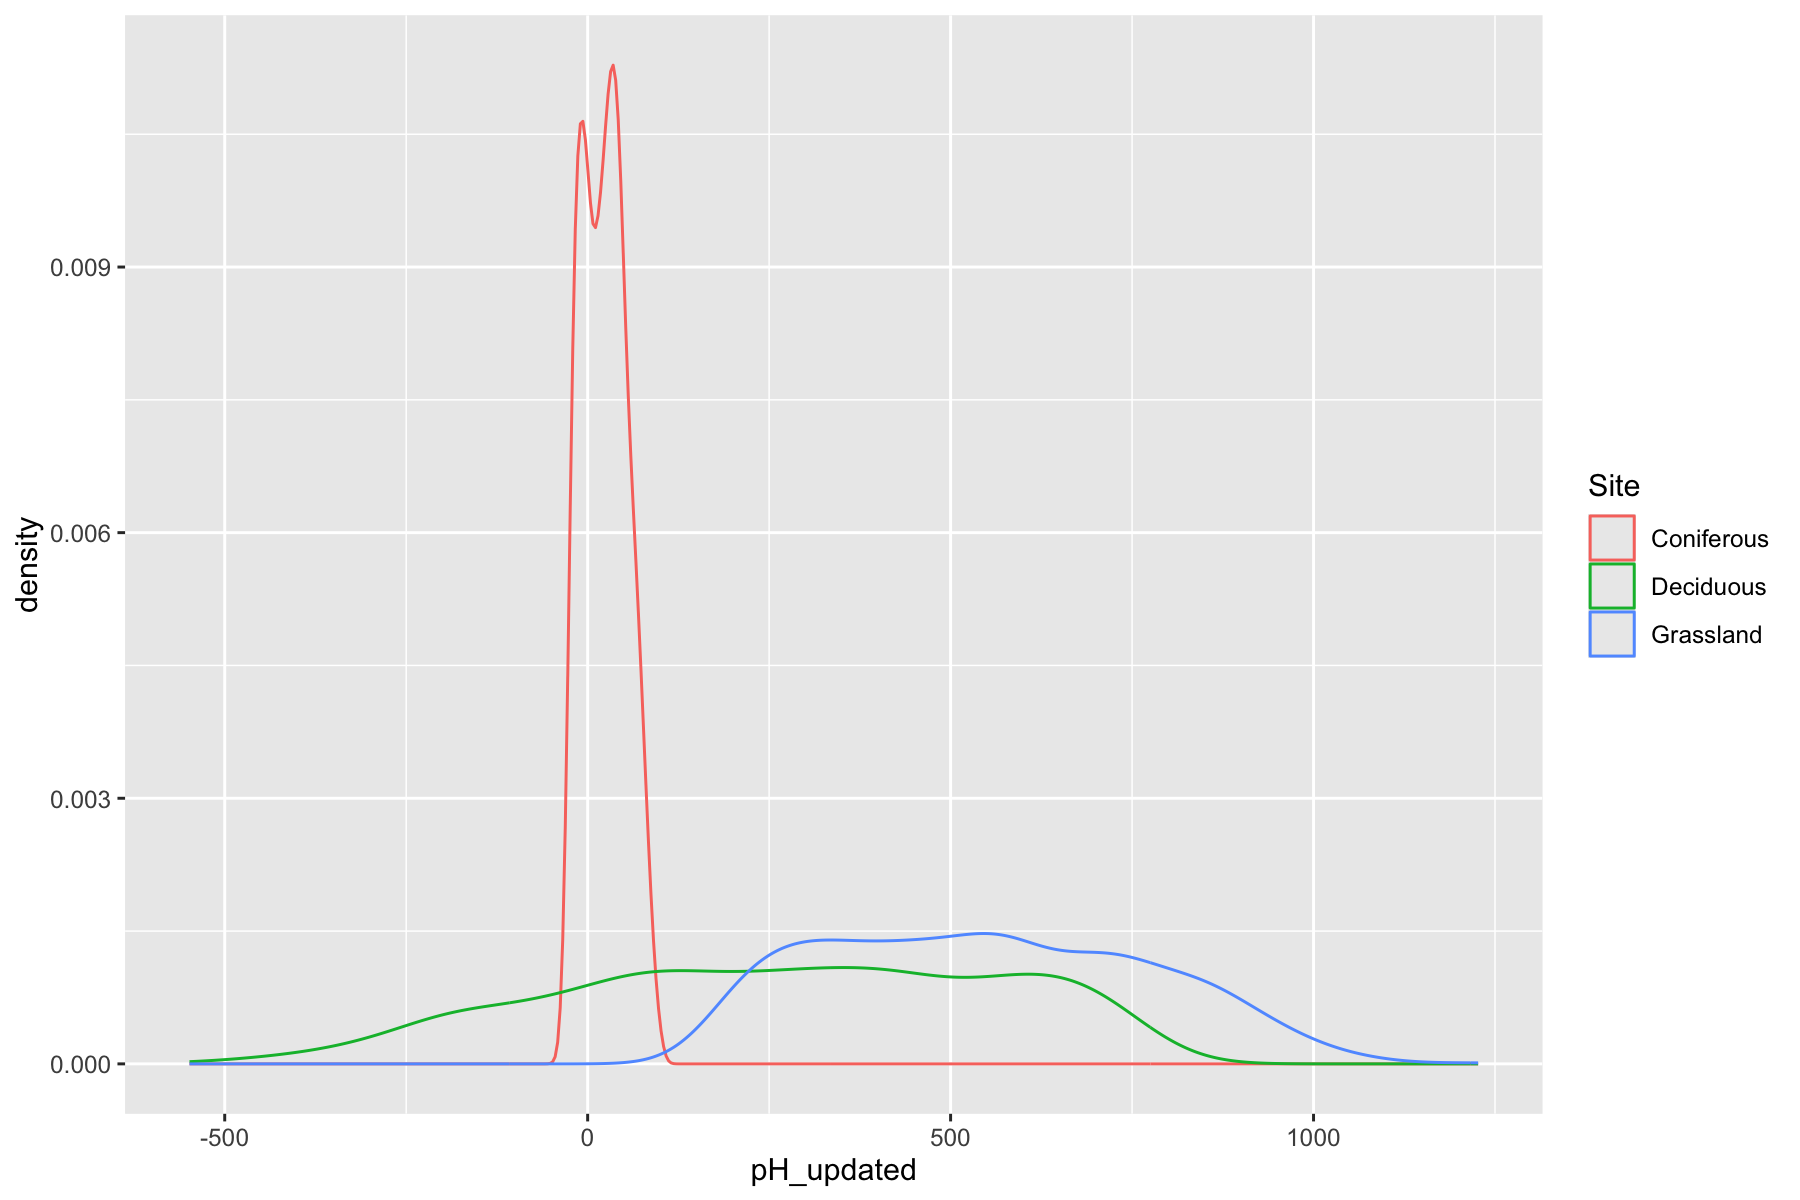

In [15]:
ggplot(df_1, 
       aes(x = pH_updated, 
           colour = Site))+
  geom_density()

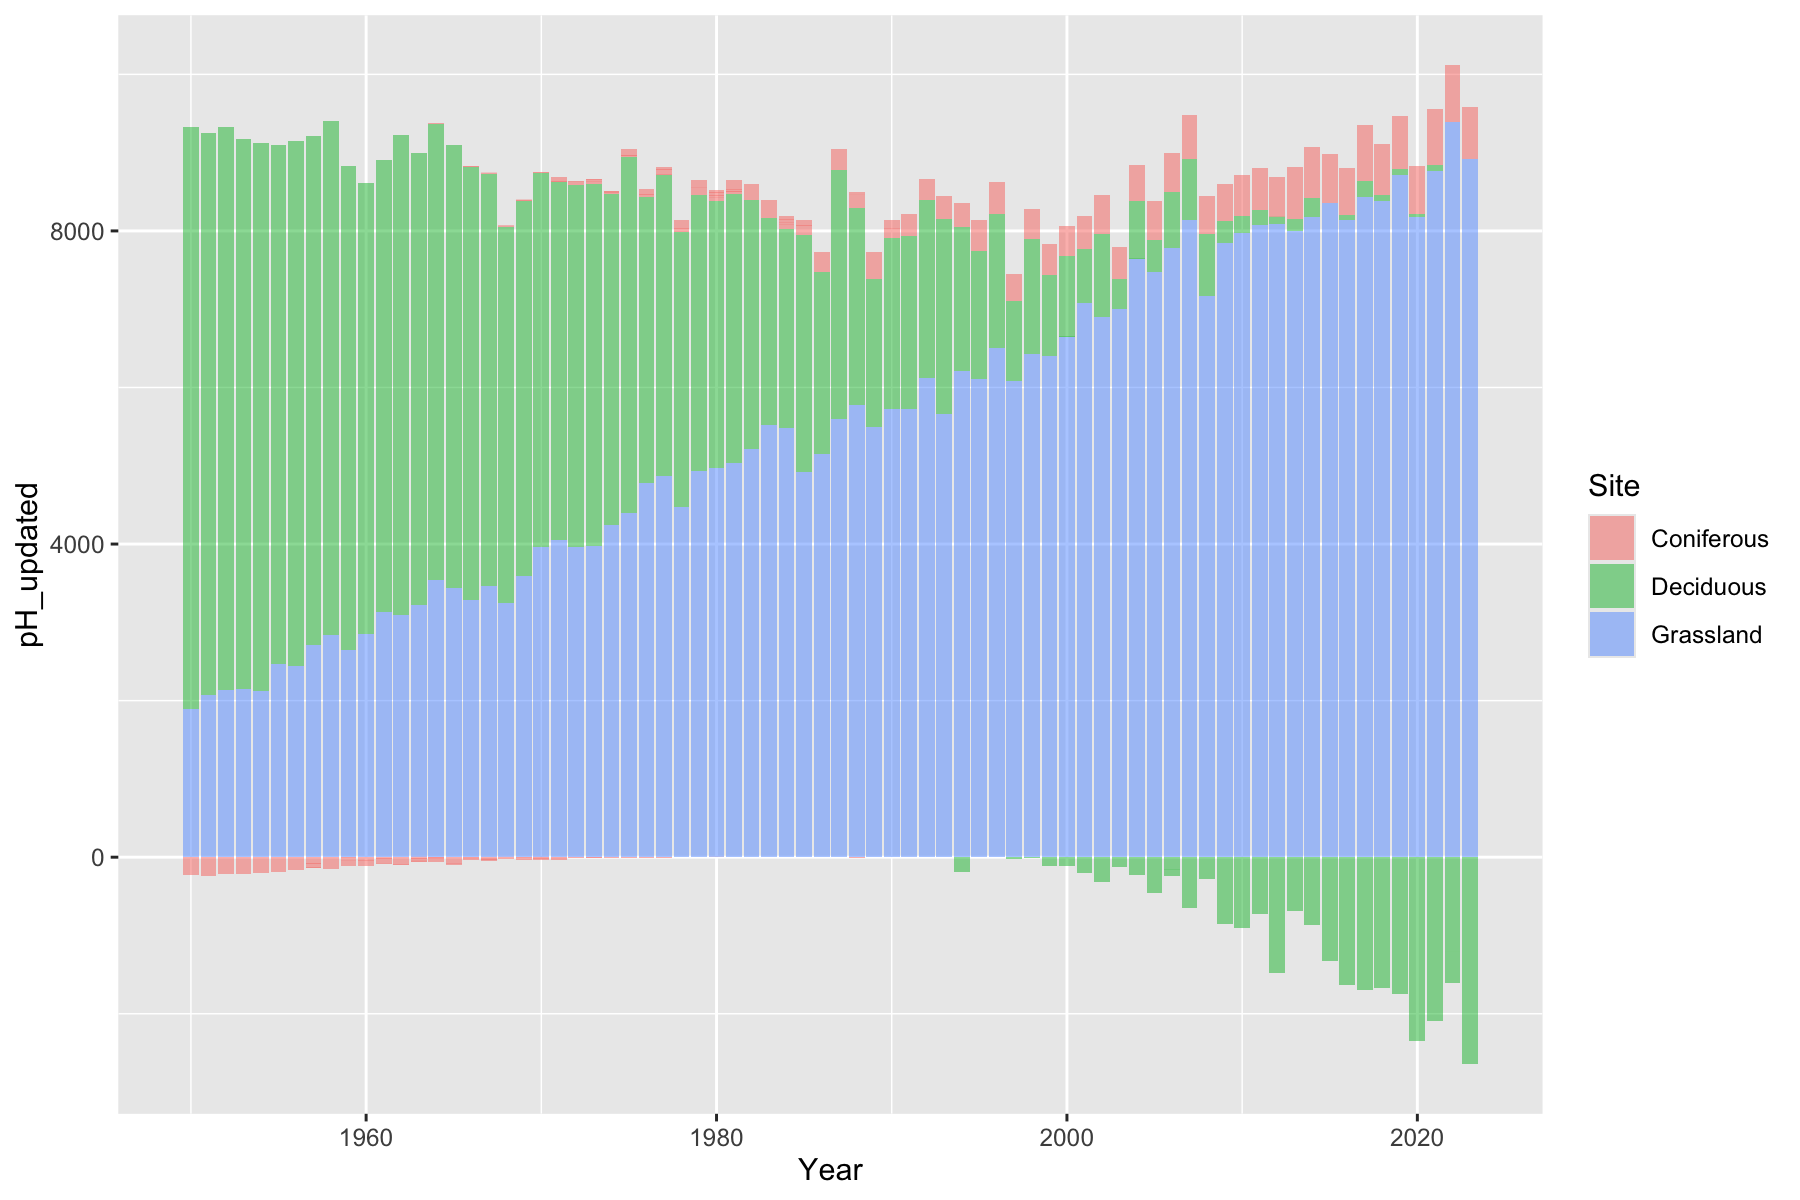

In [16]:
ggplot(df_1, 
       aes(x = Year,
           y = pH_updated,
           fill = Site))+
  geom_col(alpha = 0.5)

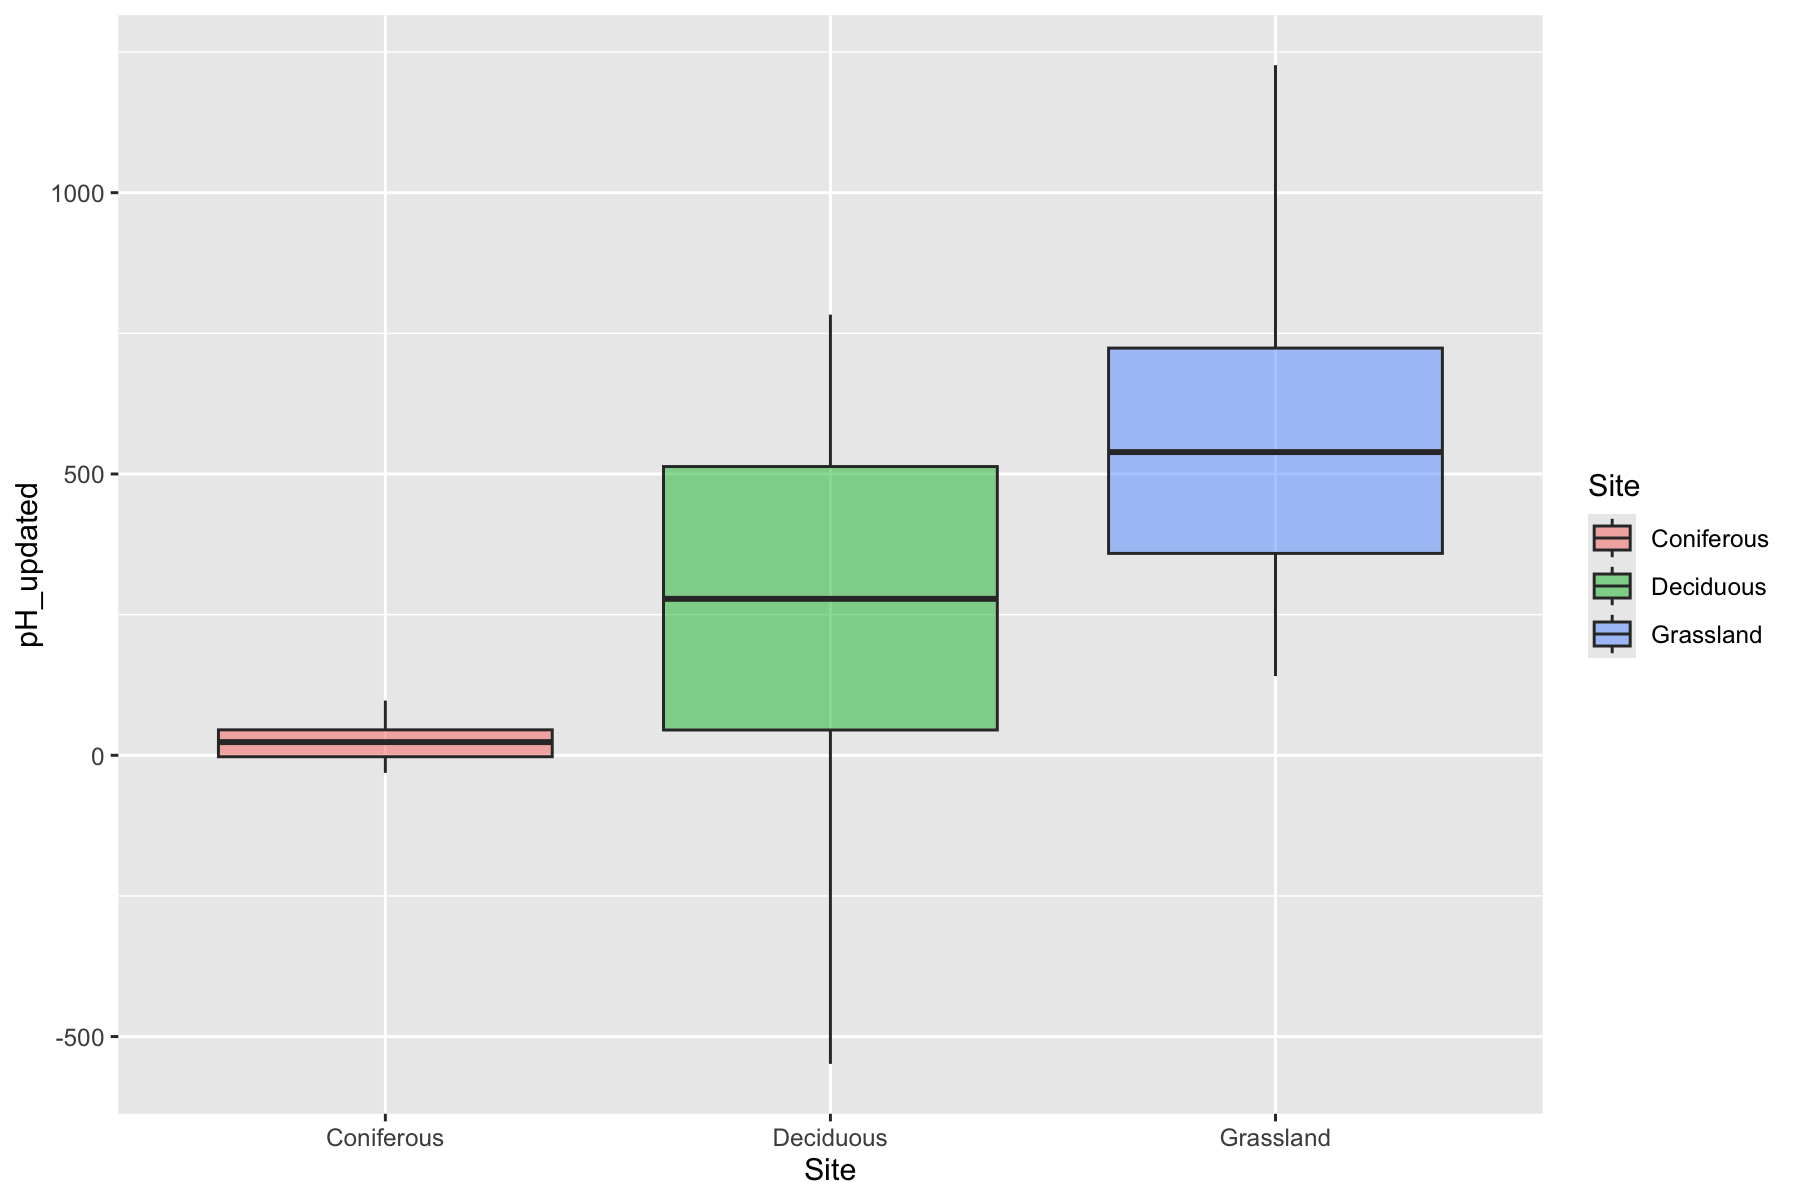

In [17]:
ggplot(df_1,
       aes(x = Site,
           y = pH_updated,
           fill = Site))+
  geom_boxplot(alpha = 0.5)

Another interesting thing about `ggplot()` is that we can also add new data into the existing plots, which means that we can use the summary data too. For this, we wadd the data to the geom (geometry) we want it used for.

We have boeth the fill and the colour with the same levels (Site), `ggplot()` will autometically combine these two into one legend.

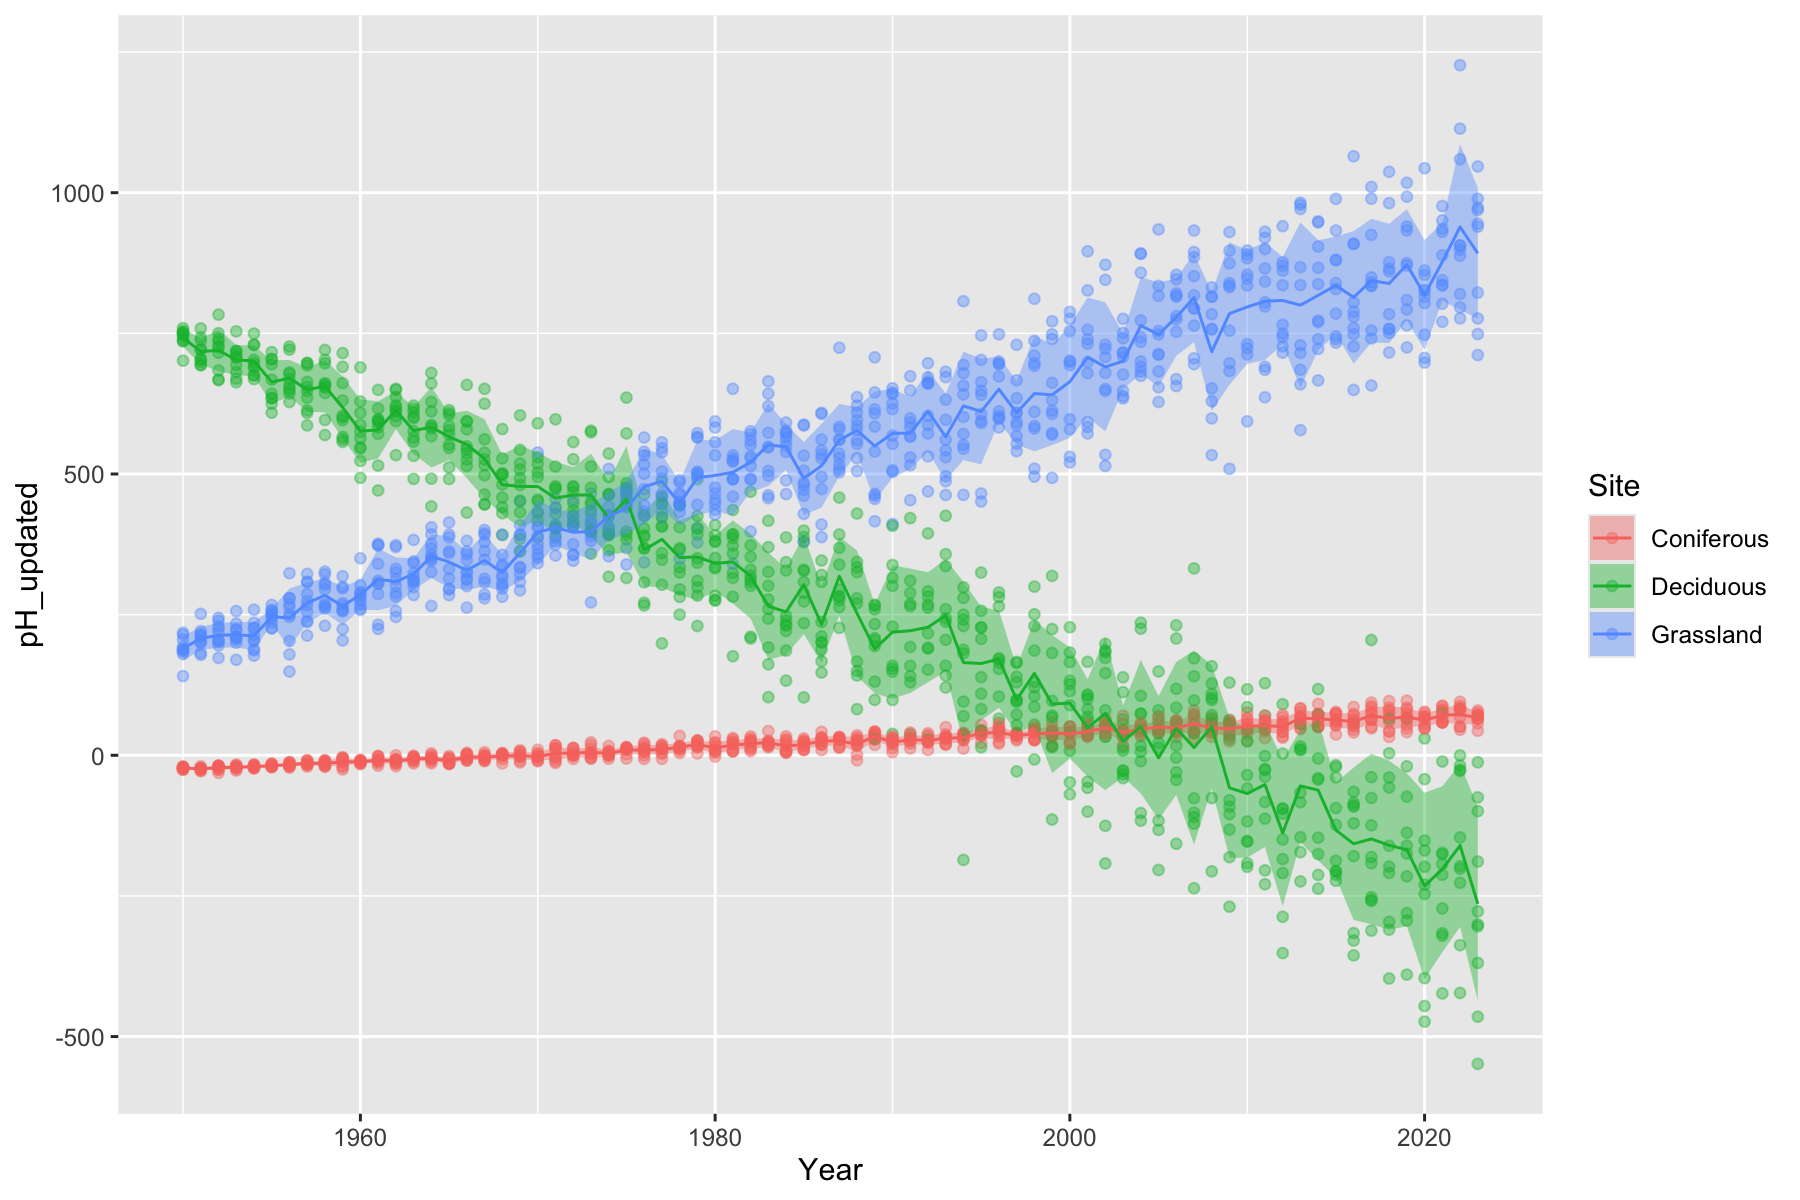

In [18]:
ggplot()+
  geom_point(data = df_1,                            # Used for point graphs
             mapping = aes(x = Year,
                           y = pH_updated,
                           colour = Site),
             alpha = 0.4)+
  geom_ribbon(data = df_1_summary_year,              # Used to display a shaded area between two continuous lines (interval of line graph)
              mapping = aes(x = Year,
                            ymax = Mean_pH + SD_pH,
                            ymin = Mean_pH - SD_pH,
                            fill = Site),
              alpha = 0.4)+
  geom_line(data = df_1_summary_year,                # Used for line graphs
            mapping = aes(x = Year,
                          y = Mean_pH,
                          colour = Site))

### Appearance

Now that we can plot slightly complex and appealing figures, we move on to changing the style and appearance of the plots. we do this by using the `theme()` function. The `theme()` function allows us to edit the alignment, the size and the shape of the title and subtitles of our plots. There are also some preset theme functions like `theme_calssic()` or `theme_bw()`. 

We can also change the appearance with our mapping elements to define the colours or fills we want using the `scale_colour_manual()` and `scale_fill_manual()` functions. This can be done for all mapping, the x or y axis can be edited with `scale_x_*()` / `scale_y_*()` functions. There are plenty of scale functions within `ggplot()` so we sometimes use a * to say that it could be any that we use.

Maybe we we want to set odd x breaks or flip the y-axis upside down, even change the colours of the plot:

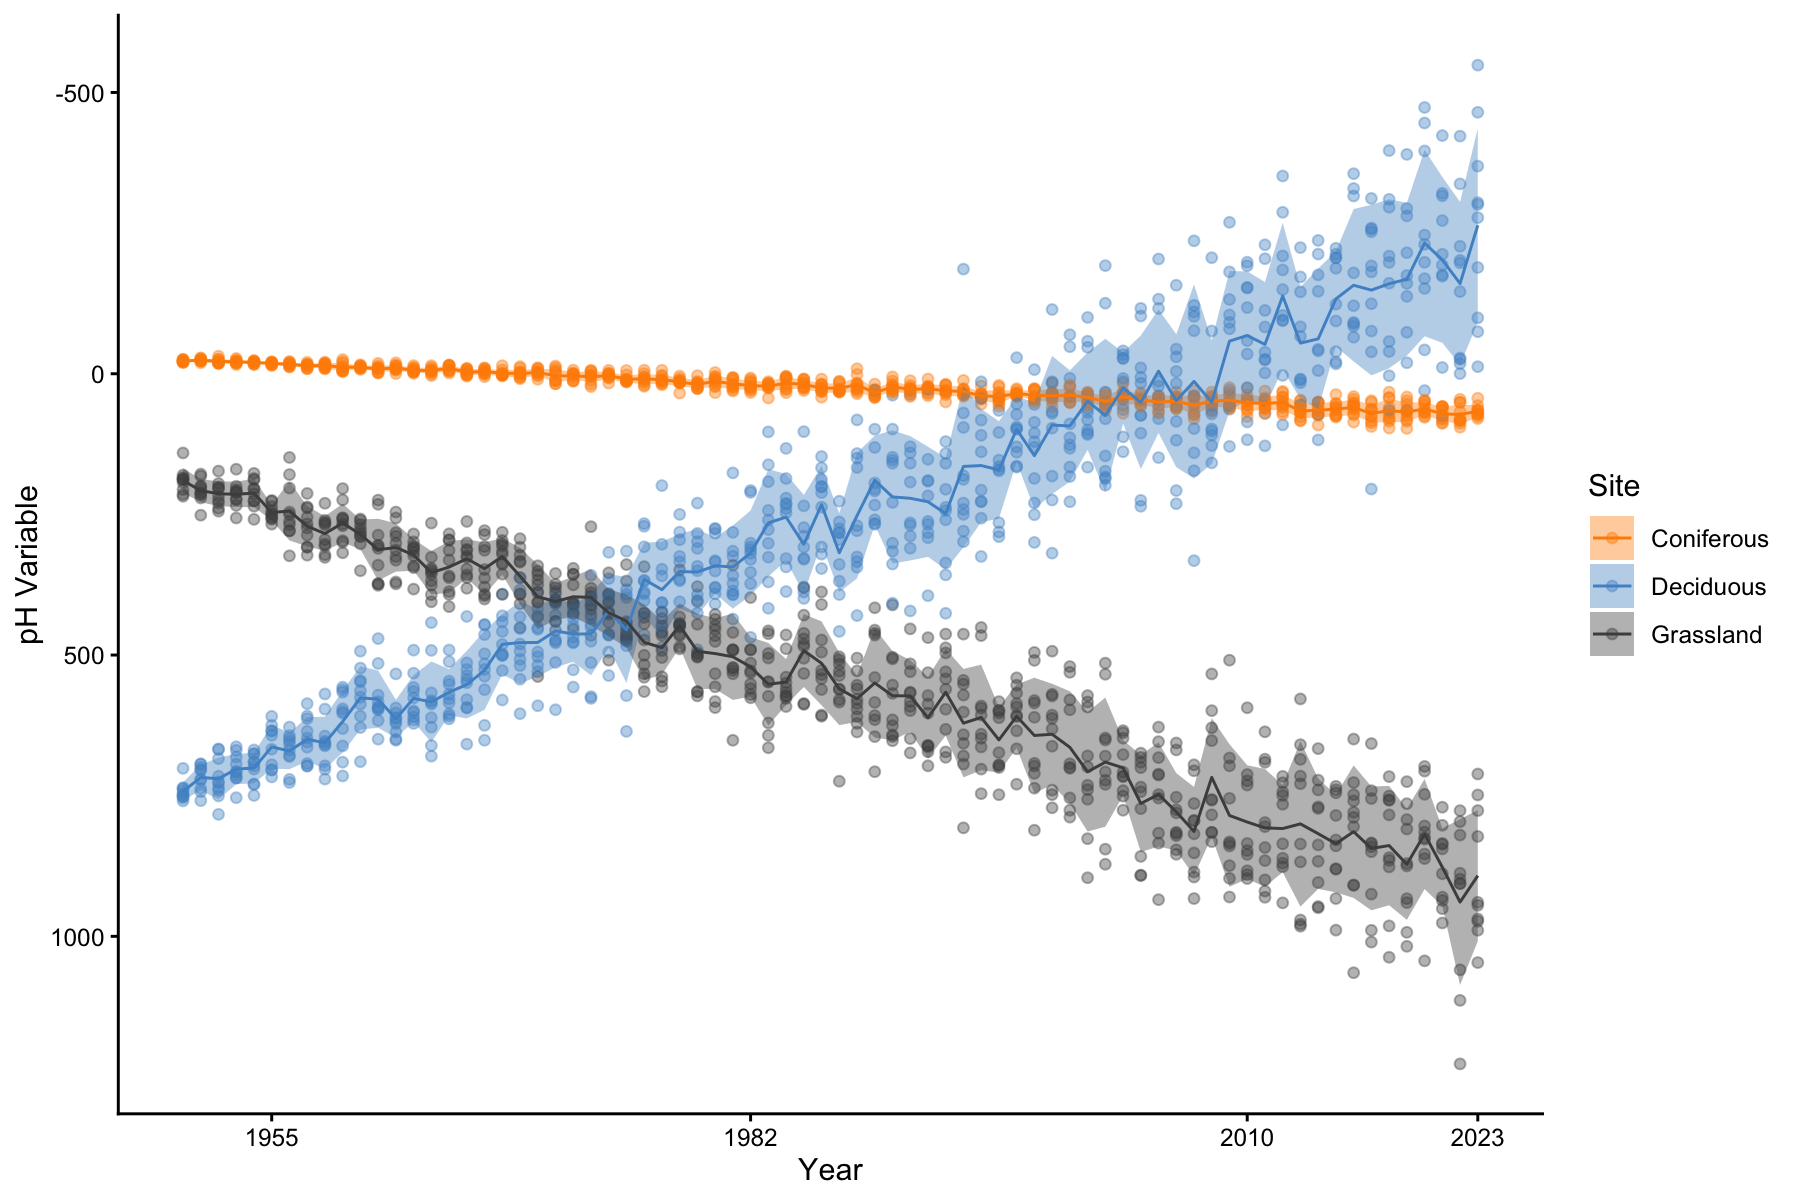

In [21]:
ggplot()+
  geom_point(data = df_1,
             mapping = aes(x = Year, 
                           y = pH_updated,
                           colour = Site),
             alpha = 0.4) +
  geom_ribbon(data = df_1_summary_year, 
              mapping = aes(x = Year, 
                            ymax = Mean_pH + SD_pH,
                            ymin = Mean_pH - SD_pH,
                            fill = Site),
              alpha = 0.4) +
  geom_line(data = df_1_summary_year,
            mapping = aes(x = Year,
                          y = Mean_pH,
                          colour = Site)) +
  scale_colour_manual(values = c("darkorange", "steelblue3", "grey30")) +
  scale_fill_manual(values = c("darkorange", "steelblue3", "grey30")) +
  scale_x_continuous(breaks = c(1955, 1982, 2010, 2023)) + 
  scale_y_reverse() +
  labs(x = "Year", y = "pH Variable") +
  theme_classic()

We could even separate plots by another column using a technique called facetting

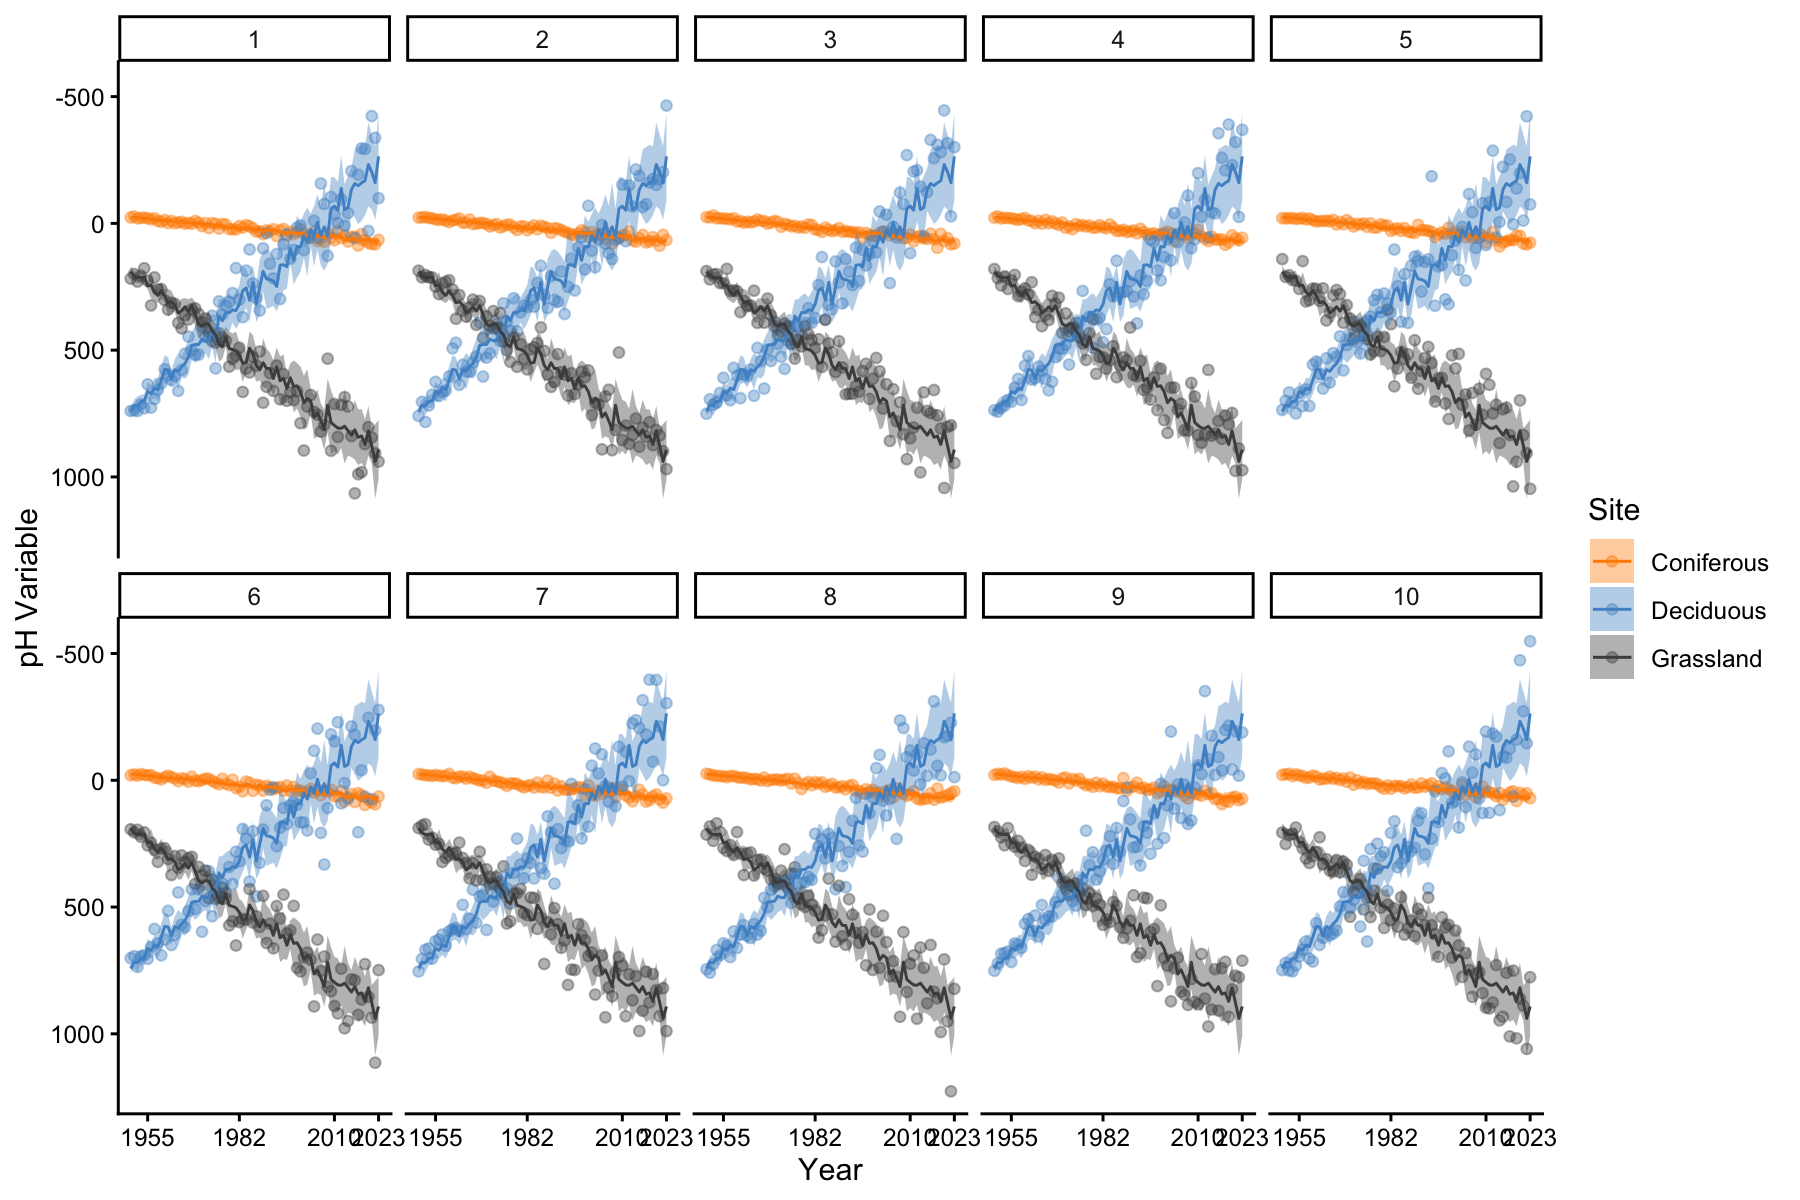

In [22]:
ggplot()+
  geom_point(data = df_1,
             mapping = aes(x = Year, 
                           y = pH_updated,
                           colour = Site),
             alpha = 0.4) +
  geom_ribbon(data = df_1_summary_year, 
              mapping = aes(x = Year, 
                            ymax = Mean_pH + SD_pH,
                            ymin = Mean_pH - SD_pH,
                            fill = Site),
              alpha = 0.4) +
  geom_line(data = df_1_summary_year,
            mapping = aes(x = Year,
                          y = Mean_pH,
                          colour = Site)) +
  facet_wrap(~Sample, nrow = 2) +
  scale_colour_manual(values = c("darkorange", "steelblue3", "grey30")) +
  scale_fill_manual(values = c("darkorange", "steelblue3", "grey30")) +
  scale_x_continuous(breaks = c(1955, 1982, 2010, 2023)) + 
  scale_y_reverse() +
  labs(x = "Year", y = "pH Variable") +
  theme_classic()

We can add up different layers but also edit all elements of the plot using either the `theme()` or `scale_*_()` functions. I will leave it up to you to find out about the different types of themes `ggplot()` offers. 

To add a background for our plots, we can say `plot.background = element_rect(fill = “grey80”)`. This will mean that the rectangular element of the plot background will be filled with the colour **grey80**

`panel.grid.major.y = element_line(colour = “green”,linetype = “dotdash”,linewidth = 2)` will mean that the axis lines element of the panel background will be a green dotdashed line of linewidth 2 with the colour **grey80**

We can add titles and subtitles or change the legend title inside the labs function (if we only change the fill title it will split the colour and fill legends). We can even add geoms that are labels or texts or other shapes/lines not base on our data.

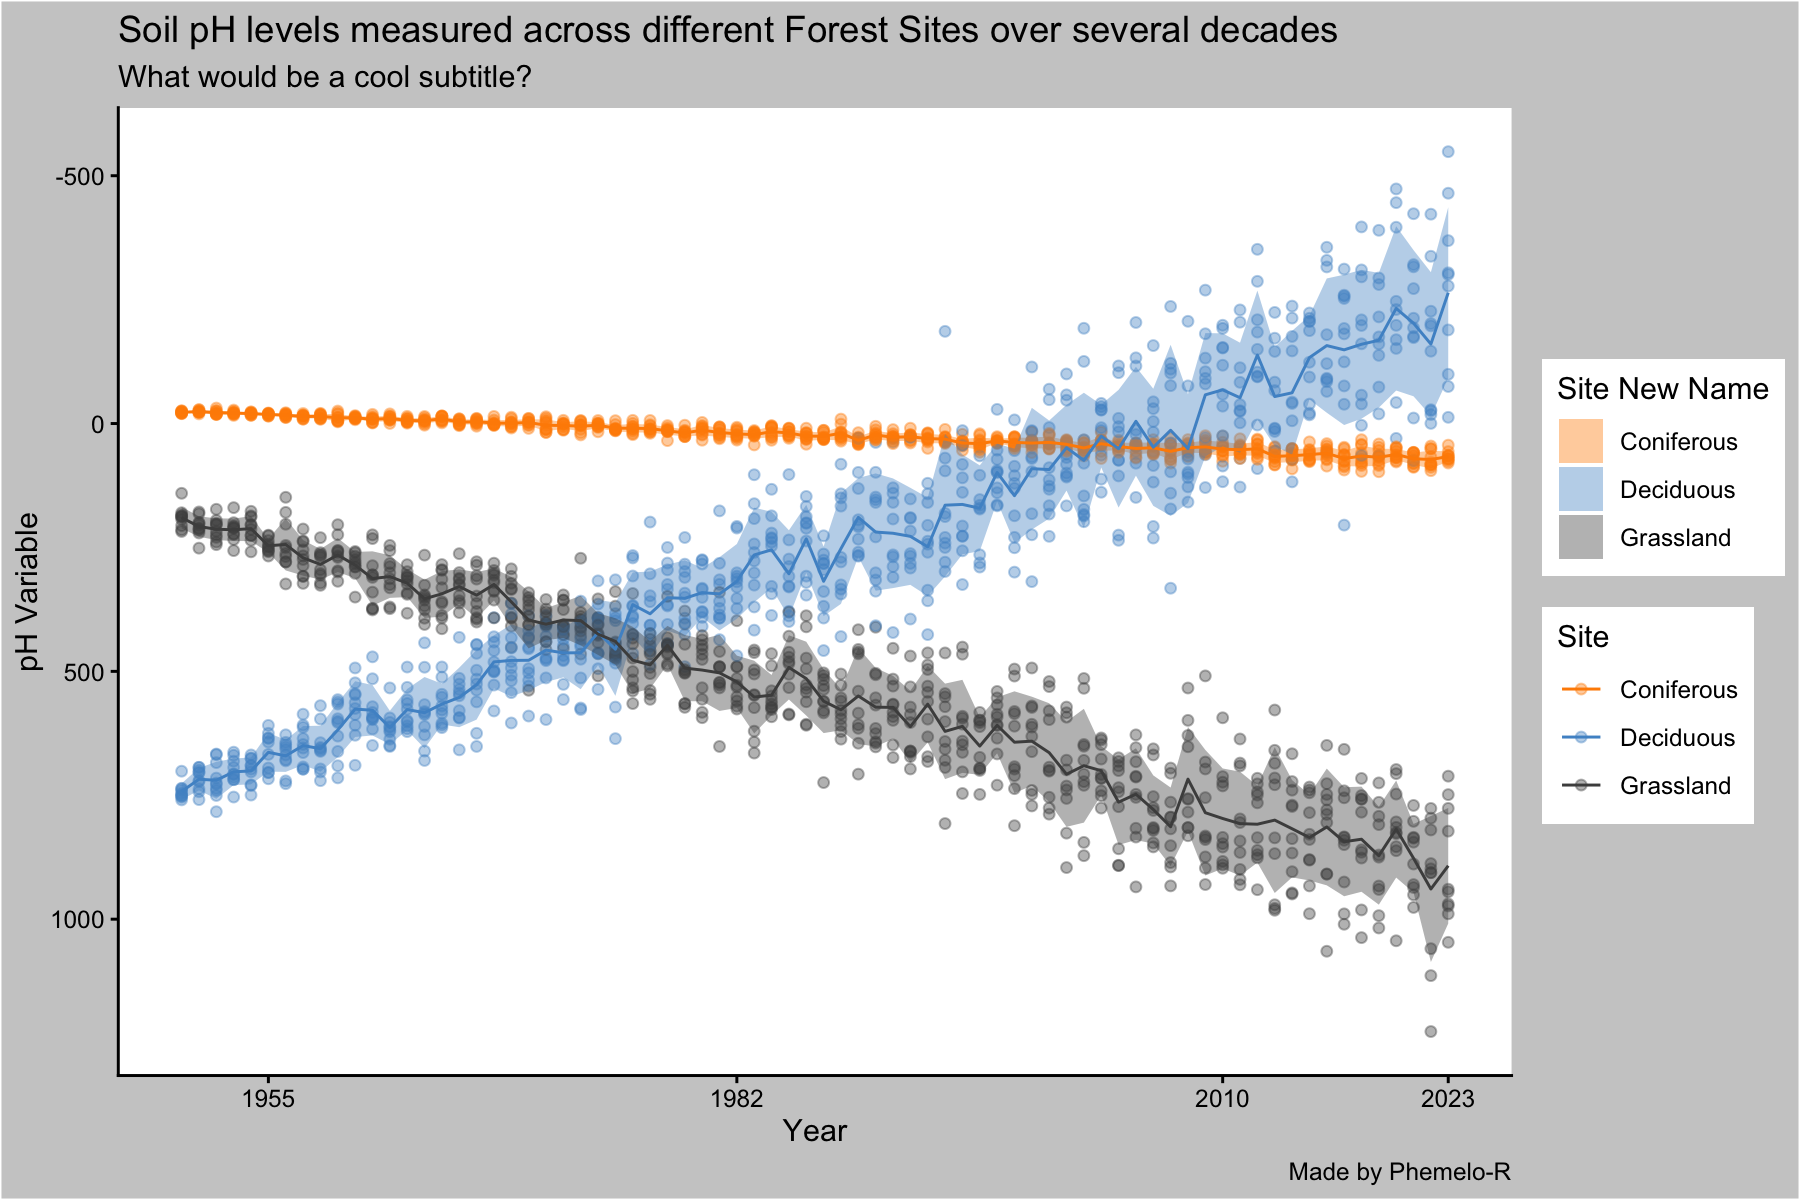

In [25]:
ggplot()+
  geom_point(data = df_1,
             mapping = aes(x = Year, 
                           y = pH_updated,
                           colour = Site),
             alpha = 0.4) +
  geom_ribbon(data = df_1_summary_year, 
              mapping = aes(x = Year, 
                            ymax = Mean_pH + SD_pH,
                            ymin = Mean_pH - SD_pH,
                            fill = Site),
              alpha = 0.4) +
  geom_line(data = df_1_summary_year,
            mapping = aes(x = Year,
                          y = Mean_pH,
                          colour = Site)) +
  scale_colour_manual(values = c("darkorange", "steelblue3", "grey30")) +
  scale_fill_manual(values = c("darkorange", "steelblue3", "grey30")) +
  scale_x_continuous(breaks = c(1955, 1982, 2010, 2023)) + 
  scale_y_reverse() +
  labs(x = "Year", 
       y = "pH Variable", 
       fill = "Site New Name",
       title = "Soil pH levels measured across different Forest Sites over several decades",
       subtitle = "What would be a cool subtitle?",
       caption = "Made by Phemelo-R"
       ) +
  theme_classic() +
  theme(plot.background = element_rect(fill="grey80")
        )

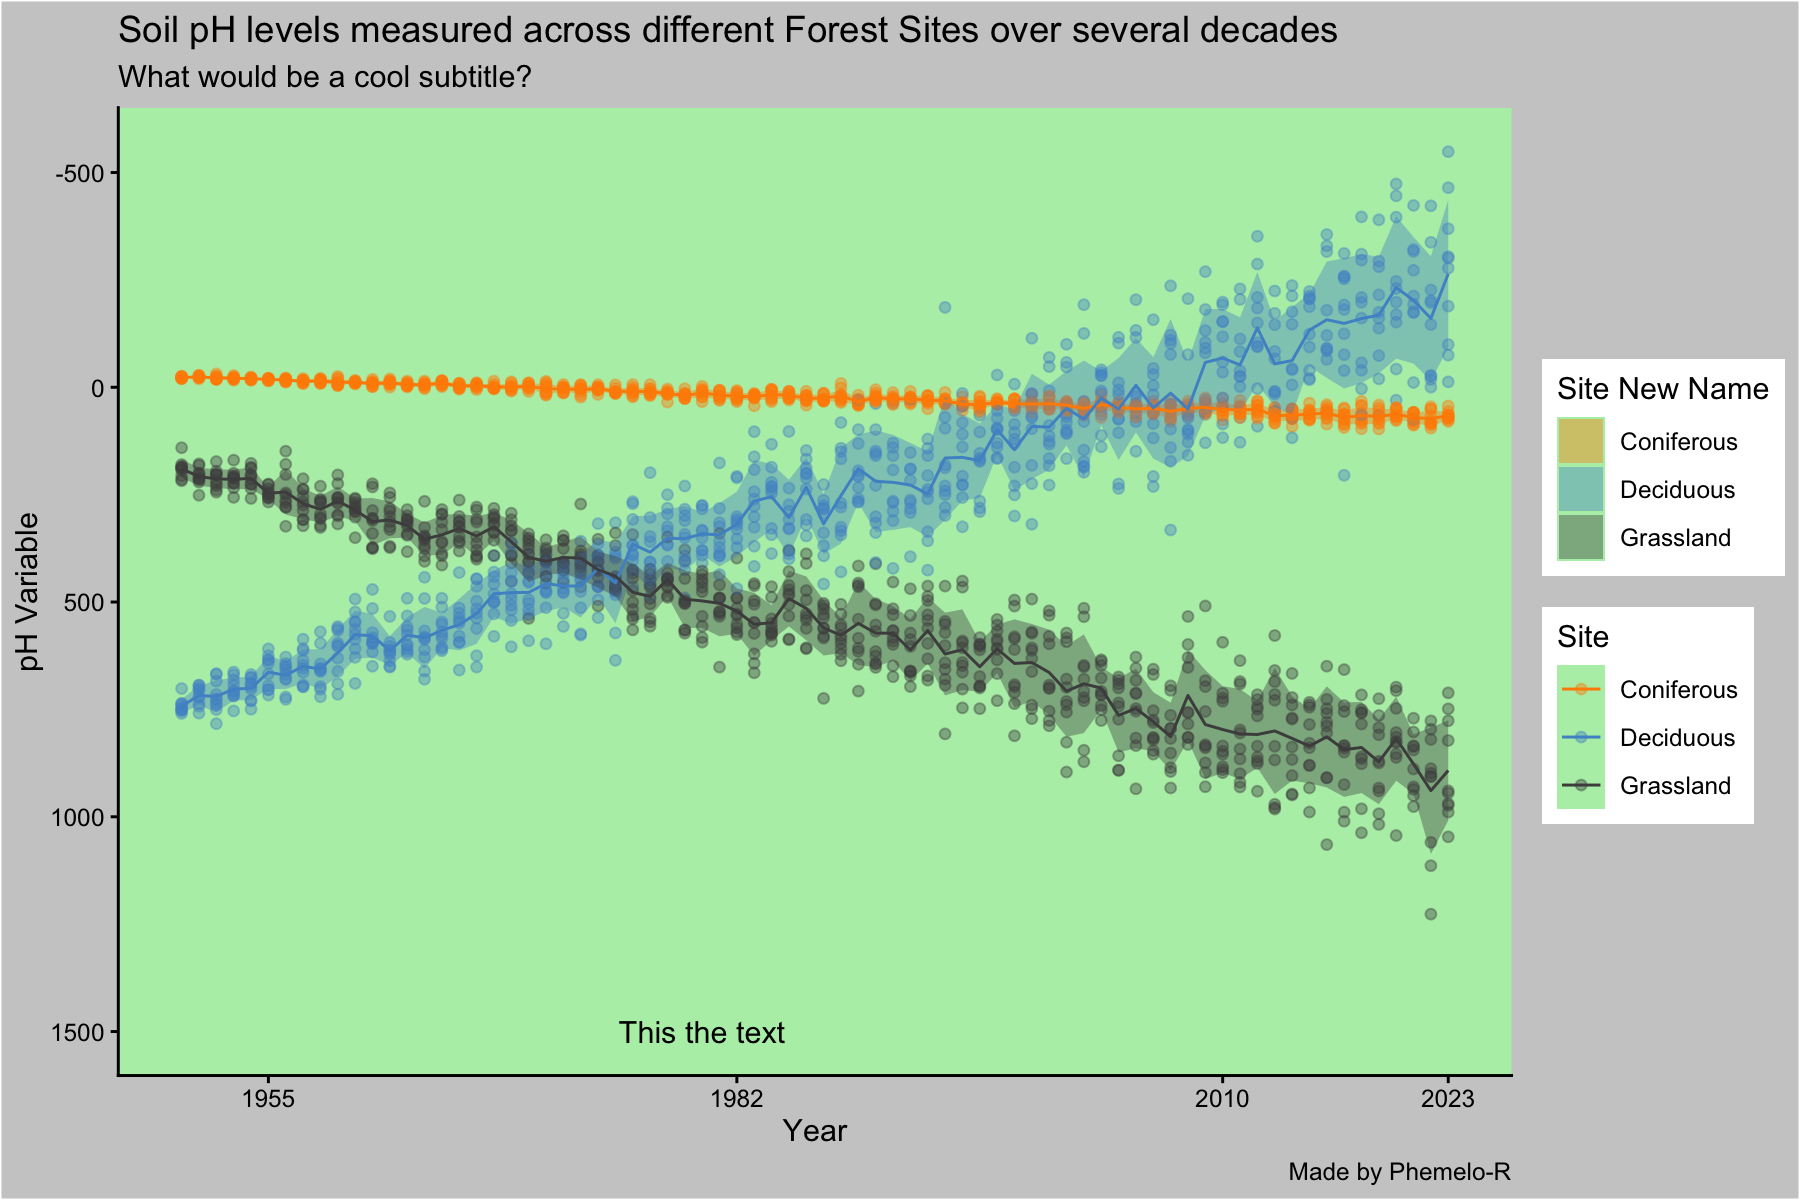

In [29]:
ggplot()+
  geom_point(data = df_1,
             mapping = aes(x = Year, 
                           y = pH_updated,
                           colour = Site),
             alpha = 0.4) +
  geom_ribbon(data = df_1_summary_year, 
              mapping = aes(x = Year, 
                            ymax = Mean_pH + SD_pH,
                            ymin = Mean_pH - SD_pH,
                            fill = Site),
              alpha = 0.4) +
  geom_line(data = df_1_summary_year,
            mapping = aes(x = Year,
                          y = Mean_pH,
                          colour = Site)) +
  scale_colour_manual(values = c("darkorange", "steelblue3", "grey30")) +
  scale_fill_manual(values = c("darkorange", "steelblue3", "grey30")) +
  scale_x_continuous(breaks = c(1955, 1982, 2010, 2023)) + 
  scale_y_reverse() +
  labs(x = "Year", 
       y = "pH Variable", 
       fill = "Site New Name",
       title = "Soil pH levels measured across different Forest Sites over several decades",
       subtitle = "What would be a cool subtitle?",
       caption = "Made by Phemelo-R"
       ) +
  theme_classic() +
  theme(plot.background = element_rect(fill="grey80"),
        panel.background = element_rect(fill = "darkseagreen2")
        ) +
  geom_text(aes(x = 1980,
                y = 1500,
                label = "This the text"))

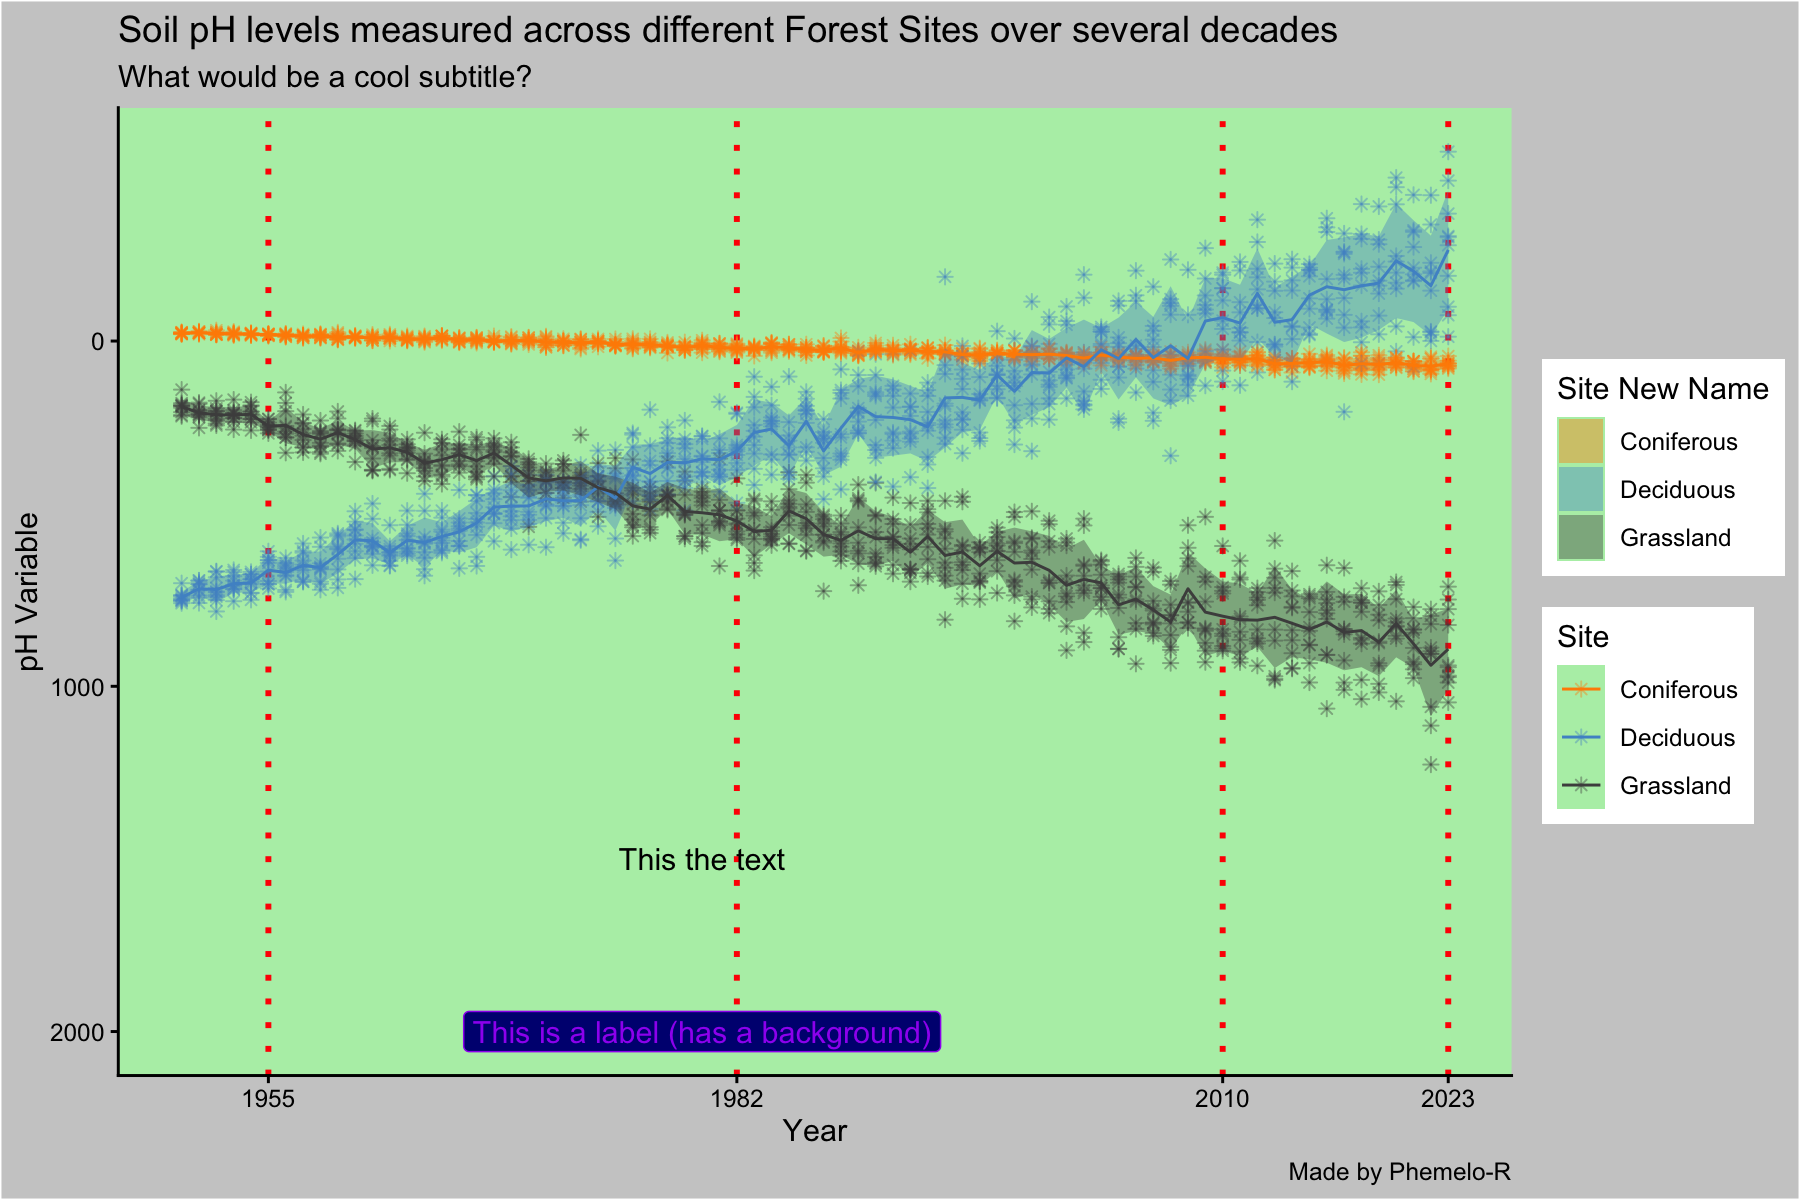

In [31]:
ggplot()+
  geom_point(data = df_1,
             mapping = aes(x = Year, 
                           y = pH_updated,
                           colour = Site),
             alpha = 0.4,
             shape = 8) +
  geom_ribbon(data = df_1_summary_year, 
              mapping = aes(x = Year, 
                            ymax = Mean_pH + SD_pH,
                            ymin = Mean_pH - SD_pH,
                            fill = Site),
              alpha = 0.4) +
  geom_line(data = df_1_summary_year,
            mapping = aes(x = Year,
                          y = Mean_pH,
                          colour = Site)) +
  scale_colour_manual(values = c("darkorange", "steelblue3", "grey30")) +
  scale_fill_manual(values = c("darkorange", "steelblue3", "grey30")) +
  scale_x_continuous(breaks = c(1955, 1982, 2010, 2023)) + 
  scale_y_reverse() +
  labs(x = "Year", 
       y = "pH Variable", 
       fill = "Site New Name",
       title = "Soil pH levels measured across different Forest Sites over several decades",
       subtitle = "What would be a cool subtitle?",
       caption = "Made by Phemelo-R"
       ) +
  theme_classic() +
  theme(plot.background = element_rect(fill="grey80"),
        panel.background = element_rect(fill = "darkseagreen2"),
        panel.grid.major.x = element_line(colour = "red",linetype = "dotted",linewidth =1)
        ) +
  geom_text(aes(x = 1980, y = 1500, label = "This the text")) +
  geom_label(aes(x = 1980, y = 2000, label = "This is a label (has a background)"), colour = "purple", fill = "navyblue")

The plot above is horrible, but it shows different important elements we might want to add or take away from plots. Once we have got a plot, we will have to find a way to save it on our computer. we will do so my using the `ggsave()` function. To do this we can save our plot as an object, then provide the location we want to save the file and its name as well as the extensipn in quotations, and its size.

We will save to the Figures directory

In [33]:
# Saving the more scientific plot
Plot_to_save <- ggplot()+
  geom_point(data = df_1,
             mapping = aes(x = Year, 
                           y = pH_updated,
                           colour = Site),
             alpha = 0.4) +
  geom_ribbon(data = df_1_summary_year, 
              mapping = aes(x = Year, 
                            ymax = Mean_pH + SD_pH,
                            ymin = Mean_pH - SD_pH,
                            fill = Site),
              alpha = 0.4) +
  geom_line(data = df_1_summary_year,
            mapping = aes(x = Year,
                          y = Mean_pH,
                          colour = Site)) +
  scale_colour_manual(values = c("darkorange", "steelblue3", "grey30")) +
  scale_fill_manual(values = c("darkorange", "steelblue3", "grey30")) +
  scale_x_continuous(breaks = c(1955, 1982, 2010, 2023)) + 
  scale_y_reverse() +
  labs(x = "Year", y = "pH Variable") +
  theme_classic()

ggsave("Figures/Soil_pH_plot.png", Plot_to_save, width=10, height=10) 
# Dont forget to put the file type at the end!!! we will use .png because it has a higher resolution

## Optional section

### **Raincloud plot**

A raincloud plot is a graph that combines 3 visualizations:

- a density plot,
- a boxplot,
- and the raw data in the form of a dotplot or jittered points.

The advantage of this plot is that it illustrates the distribution (with the density curve), the summary measures (first, second and third quartiles, and maximum/mininum without outliers thanks to the boxplot) and the number of observations (either via a dotplot or via jittered points) all at once.

We will be using real dataset from the package `{mpg}`.

The dataset contains observations collected by the US Environmental Protection Agency on fuel economy from 1999 to 2008 for 38 popular models of cars (run ?mpg for more information about the data):

In [34]:
data <- ggplot2::mpg

Before we go any further, let’s transform the `cyl`, `drv`, `fl`, `year` and `class` variables in factor with the `transform()` function:

In [35]:
data <- transform(data,
  cyl = factor(cyl),
  drv = factor(drv),
  fl = factor(fl),
  year = factor(year),
  class = factor(class)
)

Let’s illustrate the raincloud plot, first with jittered points (more appropriate with large samples):

In [38]:
# install.packages("ggdist")
library(ggdist)

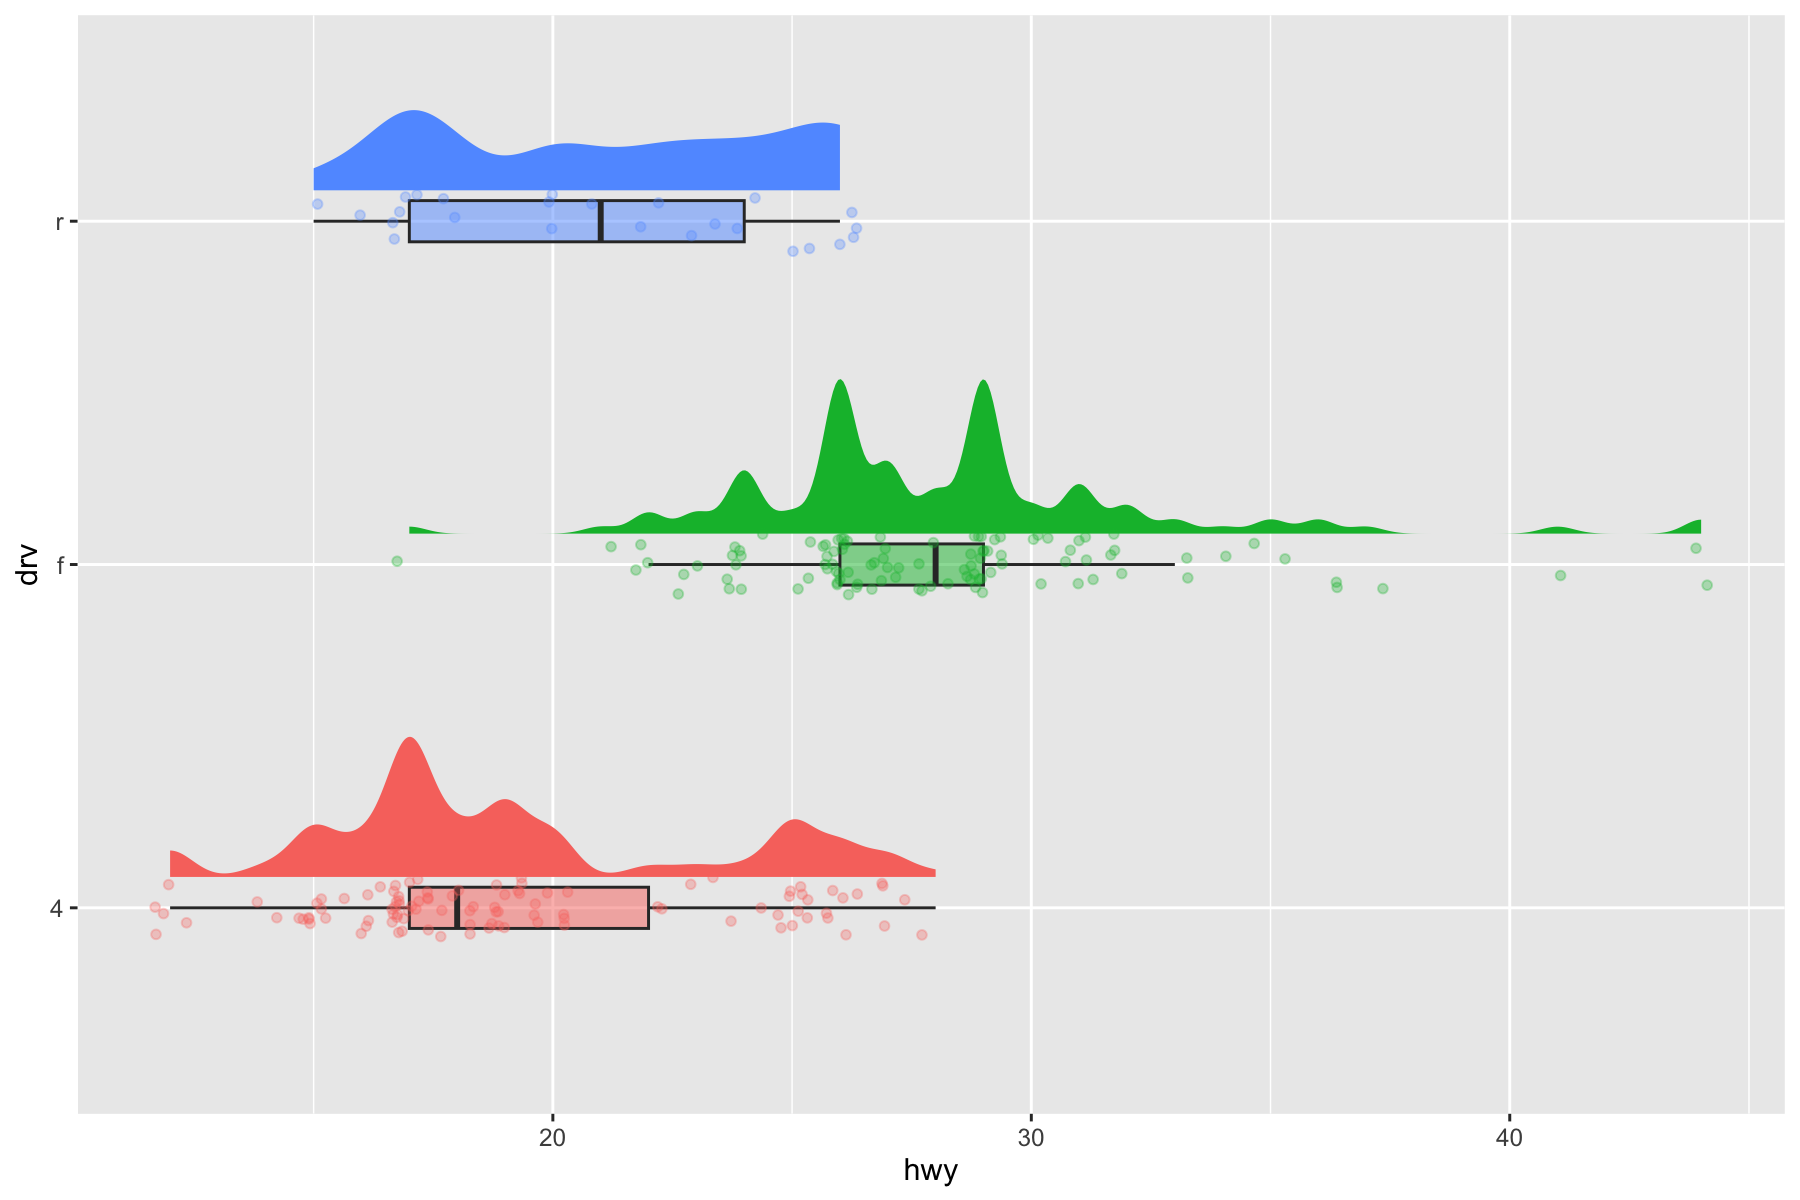

In [39]:
# Density plot:
data %>%
  ggplot(aes(x = drv, y = hwy, fill = drv)) +
  stat_halfeye(
    adjust = 0.5, # Set the smoothing parameter
    width = 0.5, # Set the height of the curves
    justification = -0.2, # Move curves to the right
    .width = 0, point_colour = NA # Remove interval present by default
  ) +
  # Boxplot:
  geom_boxplot(
    width = 0.12, # Width of boxes
    outlier.color = NA, # Remove color of outliers
    alpha = 0.5 # Add transparency
  ) +
  # Jittered points:
  geom_point(aes(colour = drv), # Add color on points
    size = 1.3, # Size of points
    alpha = .3, # aAd transparency
    position = position_jitter( # Obtain shifted points
      seed = 1, # Set seed for same random representation
      width = .09 # Manage the width of the offset
    )
  ) +
  # Further personalization:
  coord_flip() + # Rotate plot
  theme(legend.position = "none") # Remove legend

We can do the same plot, but with dotplots this time (more appropriate with small samples):

Warning message:
“The provided binwidth will cause dots to overflow the boundaries of the
geometry.
→ Set `binwidth = NA` to automatically determine a binwidth that ensures dots
  fit within the bounds,
→ OR set `overflow = "compress"` to automatically reduce the spacing between
  dots to ensure the dots fit within the bounds,
→ OR set `overflow = "keep"` to allow dots to overflow the bounds of the
  geometry without producing a warning.
ℹ For more information, see the documentation of the `binwidth` and `overflow`
  arguments of `?ggdist::geom_dots()` or the section on constraining dot sizes
  in vignette("dotsinterval") (`vignette(ggdist::dotsinterval)`).”


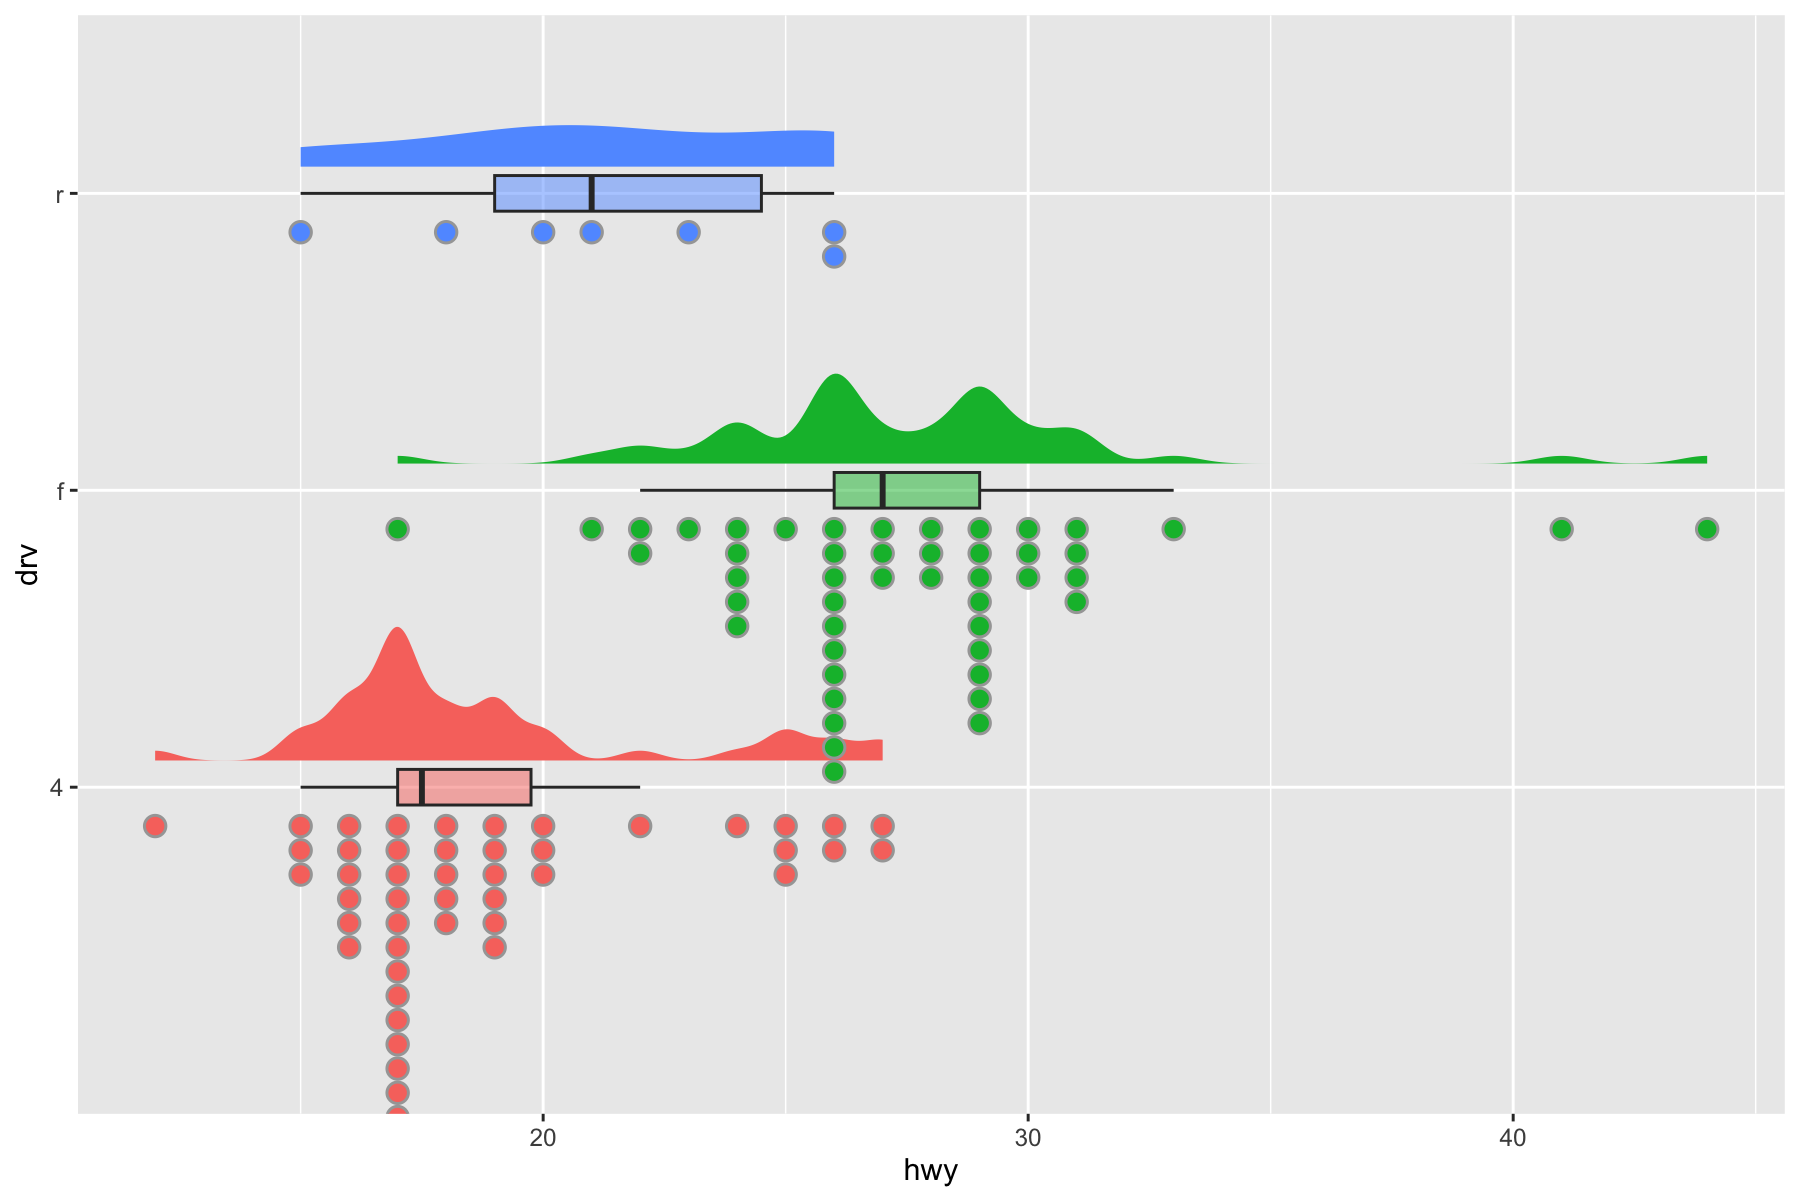

In [40]:
# Density plot:
data %>%
  sample_n(100) %>% # Random sample of size 100
  ggplot(aes(x = drv, y = hwy, fill = drv)) +
  stat_halfeye(
    adjust = 0.5, # Set the smoothing parameter
    width = 0.5, # Set the height of the curves
    justification = -0.2, # Move curves to the right
    .width = 0, point_colour = NA # Remove interval present by default
  ) +
  # Boxplot:
  geom_boxplot(
    width = 0.12, # Width of boxes
    outlier.color = NA, # Remove color of outliers
    alpha = 0.5 # Add transparency
  ) +
  # Dotplot:
  stat_dots(
    dotsize = 0.5, # Size of points
    side = "left", # Place points on opposite side of density curve
    justification = 1.1, # Move points away from boxplot
    binwidth = 1 # Group points together
  ) +
  # Further personalization:
  coord_flip() + # Rotate plot
  theme(legend.position = "none") # Remove legend

**This marks the end of this section😊**